### Basic functions

In [ ]:
import numpy as np
import pandas as pd
import time
import random
import statistics as stats
from sko.PSO import PSO
import matplotlib.pyplot as plt
from sko.DE import DE
np.random.seed(42)
random.seed(42)

# Function definitions
def rosenbrock(x):
    return sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

def griewank(x):
    part1 = sum(x**2) / 4000.0
    part2 = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return 1.0 + part1 - part2

# sweep function
def run_experiment(algo_type, func, n_dim, lb, ub, params, rounds=30, max_iter=500, pop=50, title_suffix=""):
    all_best_histories = []
    all_avg_histories = []
    final_errors = []
    
    for r in range(rounds):
        if algo_type == 'PSO':
            model = PSO(func=func, n_dim=n_dim, pop=pop, max_iter=max_iter, 
                        lb=lb, ub=ub, w=params['w'], c1=params['c1'], c2=params['c2'])
            model.record_mode = True
        elif algo_type == 'DE':
            model = DE(func=func, n_dim=n_dim, size_pop=pop, max_iter=max_iter, 
                       lb=lb, ub=ub, F=params['F'], prob_mut=params['prob_mut'])
        
        model.run()
        
        
        if algo_type == 'PSO':
            final_val = model.gbest_y[0]
            hist_Y = model.record_value['Y']
        else:
            final_val = np.atleast_1d(model.best_y)[0]
            hist_Y = model.all_history_Y 
            
        final_errors.append(final_val)
        
        
        round_best = []
        round_avg = []
        for fits in hist_Y:
            round_best.append(np.min(fits))
            round_avg.append(np.mean(fits))
            
        all_best_histories.append(round_best)
        all_avg_histories.append(round_avg)

    
    avg_min_fit = np.mean(all_best_histories, axis=0)
    std_min_fit = np.std(all_best_histories, axis=0)
    avg_pop_avg = np.mean(all_avg_histories, axis=0)

    
    plt.figure(figsize=(10, 5))
    iters = np.arange(len(avg_min_fit))
    
    
    plt.plot(iters, avg_pop_avg, label='Population Average (Mean)', color='blue', linestyle='--', alpha=0.6)
    
    
    plt.plot(iters, avg_min_fit, label='Best Fitness (Mean)', color='green', linewidth=2)
    
    plt.fill_between(iters, np.maximum(avg_min_fit - std_min_fit, 1e-15), 
                     avg_min_fit + std_min_fit, color='green', alpha=0.15)
    
    plt.yscale('log')
    plt.title(f"Detailed Evolution: {algo_type}\n{title_suffix}", fontweight='bold')
    plt.xlabel('Iteracions')
    plt.ylabel('Fitness (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", linestyle=':', alpha=0.5)
    plt.show()

    return {
        'avg': np.mean(final_errors),
        'min': np.min(final_errors),
        'std': np.std(final_errors),
        'hist_avg_min': avg_min_fit,
        'hist_std_min': std_min_fit,
        'hist_pop_avg': avg_pop_avg
    }

def plot_final_comparison(results_master, var_name, filename):
    """Genera un gràfic comparant el Millor Fitness i el Fitness Mitjà de la població."""
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.get_cmap('tab10', len(results_master))
    
    for i, (val, res) in enumerate(results_master.items()):
        iters = np.arange(len(res['hist_avg_min']))
        c = colors(i)
        
        plt.plot(iters, res['hist_avg_min'], 
                 label=f'{var_name}={val} (Best)', 
                 color=c, linewidth=2)
        
        if 'hist_pop_avg' in res:
            plt.plot(iters, res['hist_pop_avg'], 
                     color=c, linestyle='--', alpha=0.5, linewidth=1.5,
                     label=f'{var_name}={val} (Pop Avg)')
        
        plt.fill_between(iters, 
                         res['hist_avg_min'] - res['hist_std_min'], 
                         res['hist_avg_min'] + res['hist_std_min'], 
                         color=c, alpha=0.1)

    plt.yscale('log')
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Fitness (Log Scale)', fontsize=12)
    plt.title(f'Comparative Analysis: {var_name}\nSolid = Best Fitness | Dashed = Population Average', 
              fontweight='bold', fontsize=14)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    plt.grid(True, which="both", linestyle=':', alpha=0.4)
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# **Particle Swarm Optimization**

## **Griewank function**

### **Testing on w, c1 & c2**

In [ ]:

dimensions = 10
lower_bound = [-600] * dimensions 
upper_bound = [600] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150

results_pso = []
master_results = {}

print(f"Initializing Parameter Sweep - Griewank {dimensions}D...")


configs = [
    {'w': 0.8, 'c1': 0.5, 'c2': 0.5}, 
    {'w': 0.9, 'c1': 1.5, 'c2': 1.5},
    {'w': 0.4, 'c1': 2.0, 'c2': 2.0}, 
    {'w': 0.9, 'c1': 0.1, 'c2': 3.9}  
]

for cfg in configs:
    w, c1, c2 = cfg['w'], cfg['c1'], cfg['c2']
    print(f"\nTrying PSO with these parameters -> w: {w}, c1: {c1}, c2: {c2}...")
    start = time.time()
    result = run_experiment('PSO', griewank, dimensions, lower_bound, upper_bound, cfg, rounds_sweep, def_iter, def_pop, title_suffix=f"w:{w}, c1:{c1}, c2:{c2}")
    results_pso.append({'Alg': 'PSO', 'w': w, 'c1': c1, 'c2': c2, 'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']})
    label = f"w:{w}, c1:{c1}, c2:{c2}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - GRIEWANK " + str(dimensions) + "D")
print("="*70)
print(df_pso.to_string(index=False))

plot_final_comparison(master_results, var_name="w, c1, c2", filename="comparativa_final_pso_griewank_w.png")

Initializing Parameter Sweep - Griewank 10D...

Trying PSO with these parameters -> w: 0.8, c1: 0.5, c2: 0.5...


KeyboardInterrupt: 

Initializing Parameter Sweep - Griewank 10D...

Trying PSO with these parameters -> w: 0.4, c1: 2.0, c2: 2.0...


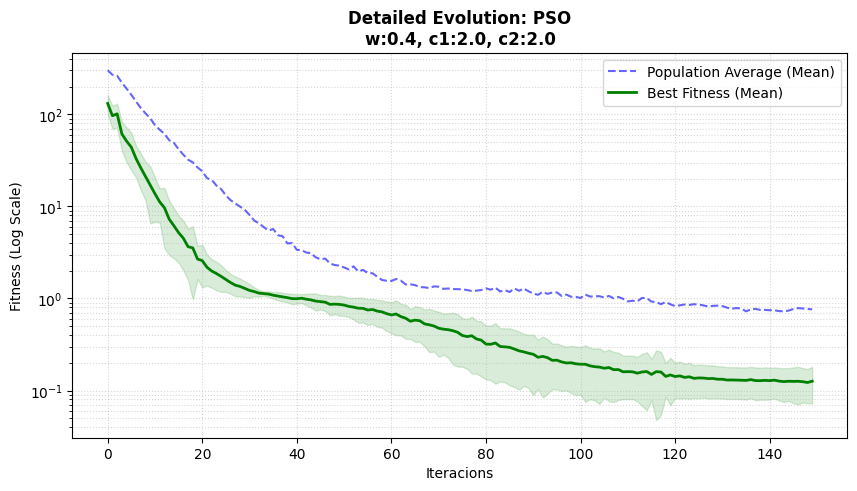

  -> Made in 1.81s | Avg: 0.1207 | Min: 0.0319 | Std: 0.0511

Trying PSO with these parameters -> w: 0.5, c1: 2.0, c2: 2.0...


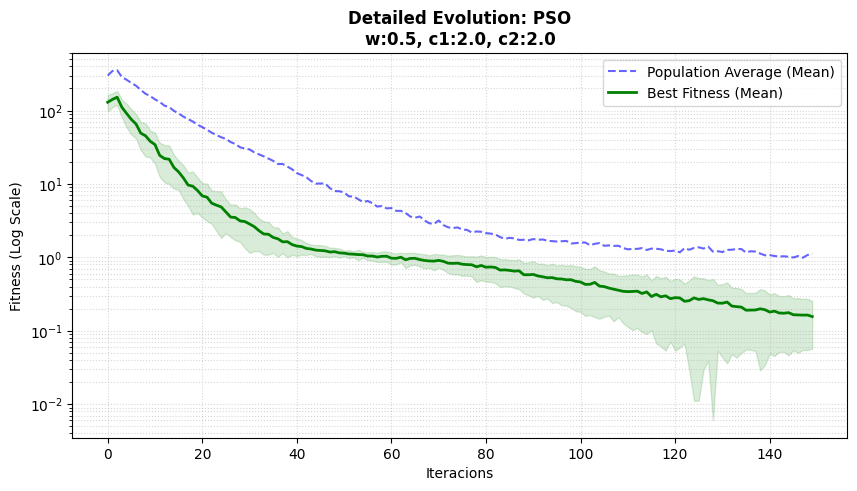

  -> Made in 1.59s | Avg: 0.1535 | Min: 0.0173 | Std: 0.0969

Trying PSO with these parameters -> w: 0.3, c1: 2.0, c2: 2.0...


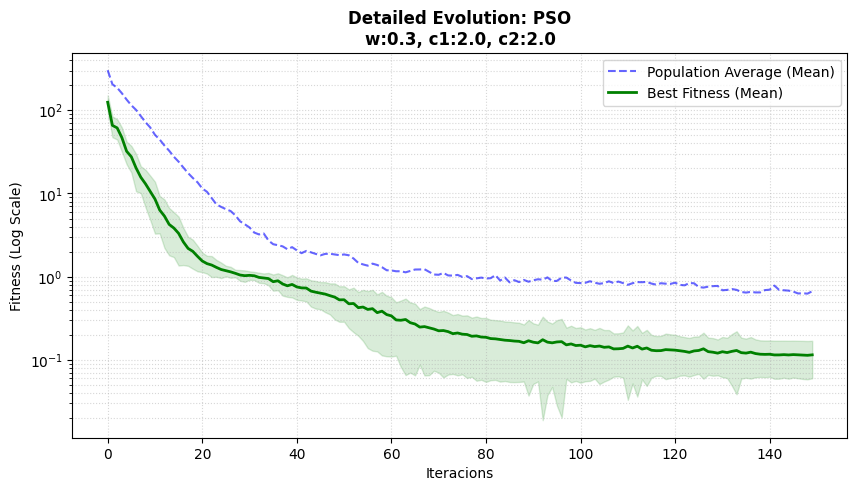

  -> Made in 1.72s | Avg: 0.1123 | Min: 0.0468 | Std: 0.0543

Trying PSO with these parameters -> w: 0.4, c1: 1.5, c2: 2.5...


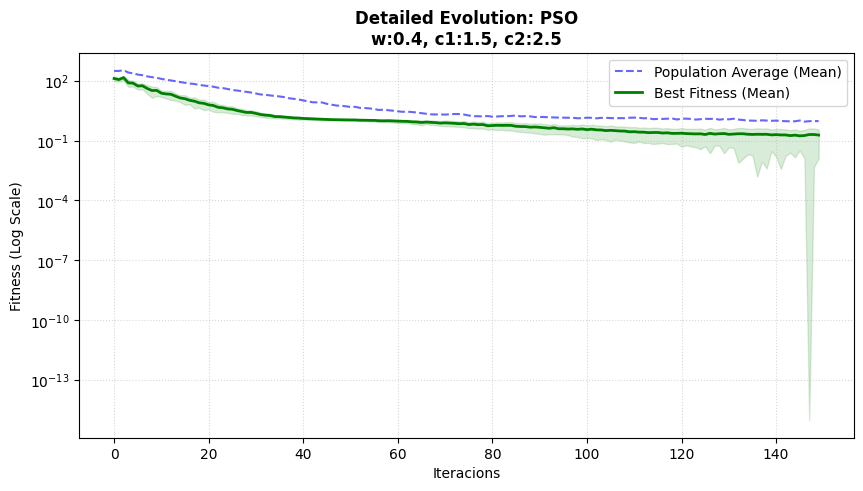

  -> Made in 1.65s | Avg: 0.1623 | Min: 0.0446 | Std: 0.1402

Trying PSO with these parameters -> w: 0.4, c1: 2.5, c2: 1.5...


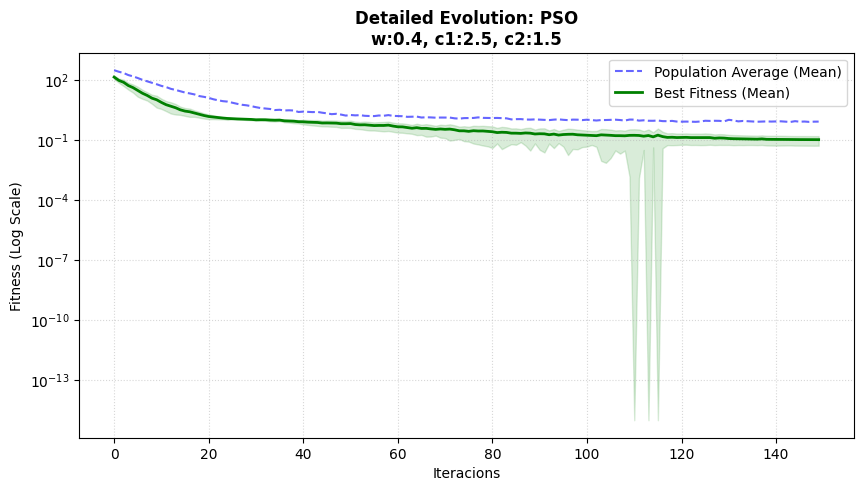

  -> Made in 1.60s | Avg: 0.1018 | Min: 0.0395 | Std: 0.0512

Trying PSO with these parameters -> w: 0.5, c1: 1.5, c2: 1.5...


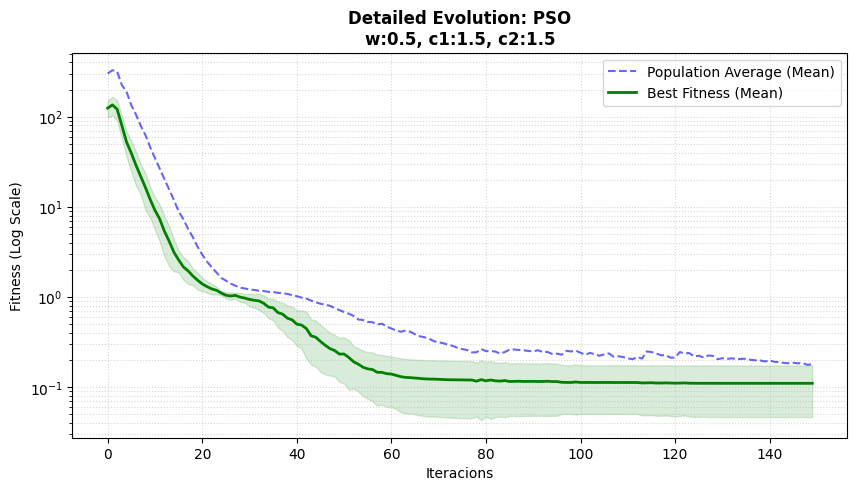

  -> Made in 1.73s | Avg: 0.1107 | Min: 0.0320 | Std: 0.0639

 RESULTS PSO - GRIEWANK 10D
Alg   w  c1  c2  Avg Fit  Min Fit  Std Dev
PSO 0.4 2.0 2.0 0.120713 0.031853 0.051134
PSO 0.5 2.0 2.0 0.153451 0.017255 0.096869
PSO 0.3 2.0 2.0 0.112343 0.046791 0.054287
PSO 0.4 1.5 2.5 0.162311 0.044557 0.140243
PSO 0.4 2.5 1.5 0.101757 0.039502 0.051241
PSO 0.5 1.5 1.5 0.110742 0.032006 0.063912


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


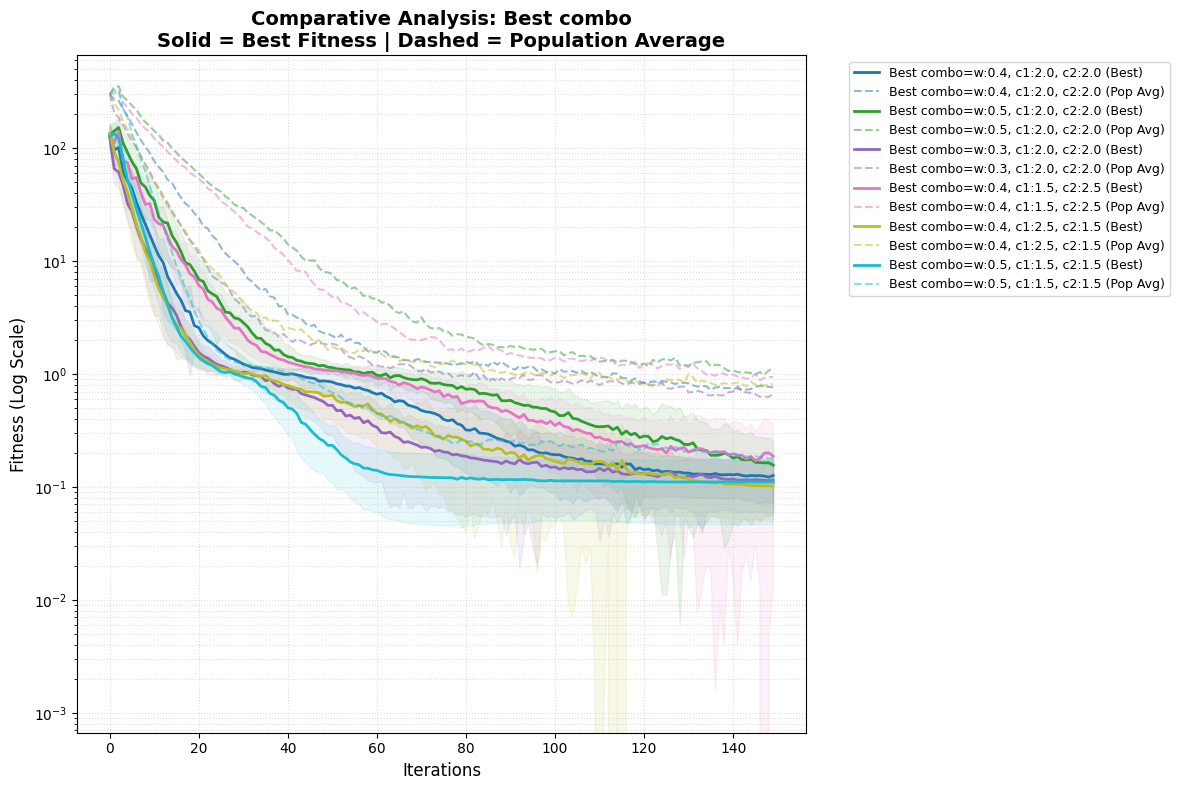

In [ ]:

dimensions = 10
lower_bound = [-600] * dimensions 
upper_bound = [600] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150

results_pso = []
master_results = {}

print(f"Initializing Parameter Sweep - Griewank {dimensions}D...")


configs_expandida = [
    {'w': 0.4, 'c1': 2.0, 'c2': 2.0},  
    {'w': 0.5, 'c1': 2.0, 'c2': 2.0},  
    {'w': 0.3, 'c1': 2.0, 'c2': 2.0},  
    {'w': 0.4, 'c1': 1.5, 'c2': 2.5},  
    {'w': 0.4, 'c1': 2.5, 'c2': 1.5},  
    {'w': 0.5, 'c1': 1.5, 'c2': 1.5},  
]

for cfg in configs_expandida:
    w, c1, c2 = cfg['w'], cfg['c1'], cfg['c2']
    print(f"\nTrying PSO with these parameters -> w: {w}, c1: {c1}, c2: {c2}...")
    start = time.time()
    result = run_experiment('PSO', griewank, dimensions, lower_bound, upper_bound, cfg, rounds_sweep, def_iter, def_pop, title_suffix=f"w:{w}, c1:{c1}, c2:{c2}")
    results_pso.append({'Alg': 'PSO', 'w': w, 'c1': c1, 'c2': c2, 'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']})
    label = f"w:{w}, c1:{c1}, c2:{c2}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso2 = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - GRIEWANK " + str(dimensions) + "D")
print("="*70)
print(df_pso2.to_string(index=False))

plot_final_comparison(master_results, var_name="Best combo", filename="comparativa_final_pso_griewank_w_expanded.png")

### **Testing on Population**

Initializing Parameter Sweep - Griewank 10D, w = 0.4, c1 = 2.5, c2 = 1.5...

Trying PSO with population 30


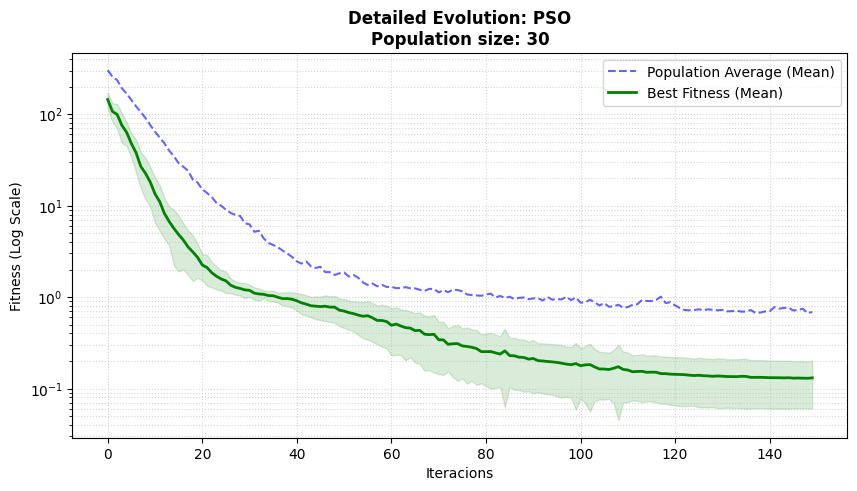

  -> Made in 1.08s | Avg: 0.1286 | Min: 0.0099 | Std: 0.0678

Trying PSO with population 50


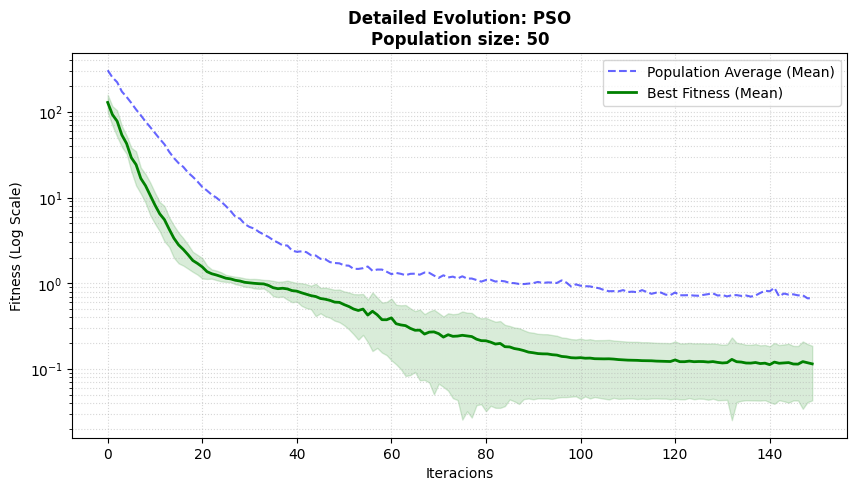

  -> Made in 1.58s | Avg: 0.1119 | Min: 0.0246 | Std: 0.0708

Trying PSO with population 200


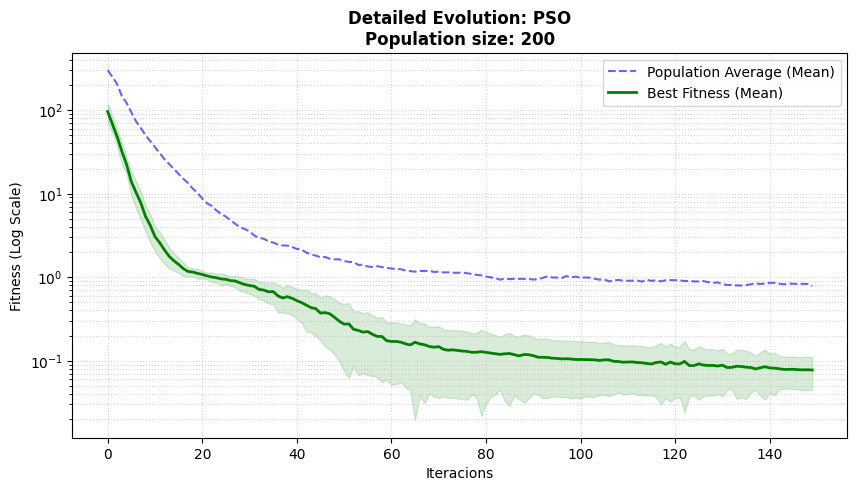

  -> Made in 5.39s | Avg: 0.0766 | Min: 0.0170 | Std: 0.0322

Trying PSO with population 600


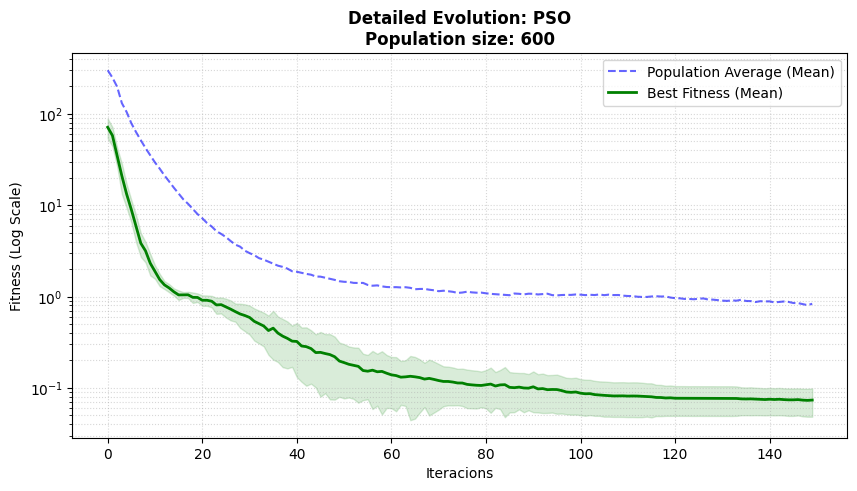

  -> Made in 15.25s | Avg: 0.0728 | Min: 0.0197 | Std: 0.0248

 RESULTS PSO - GRIEWANK 10D
Alg  population  Avg Fit  Min Fit  Std Dev
PSO          30 0.128553 0.009866 0.067793
PSO          50 0.111909 0.024644 0.070827
PSO         200 0.076620 0.016973 0.032238
PSO         600 0.072795 0.019693 0.024755


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


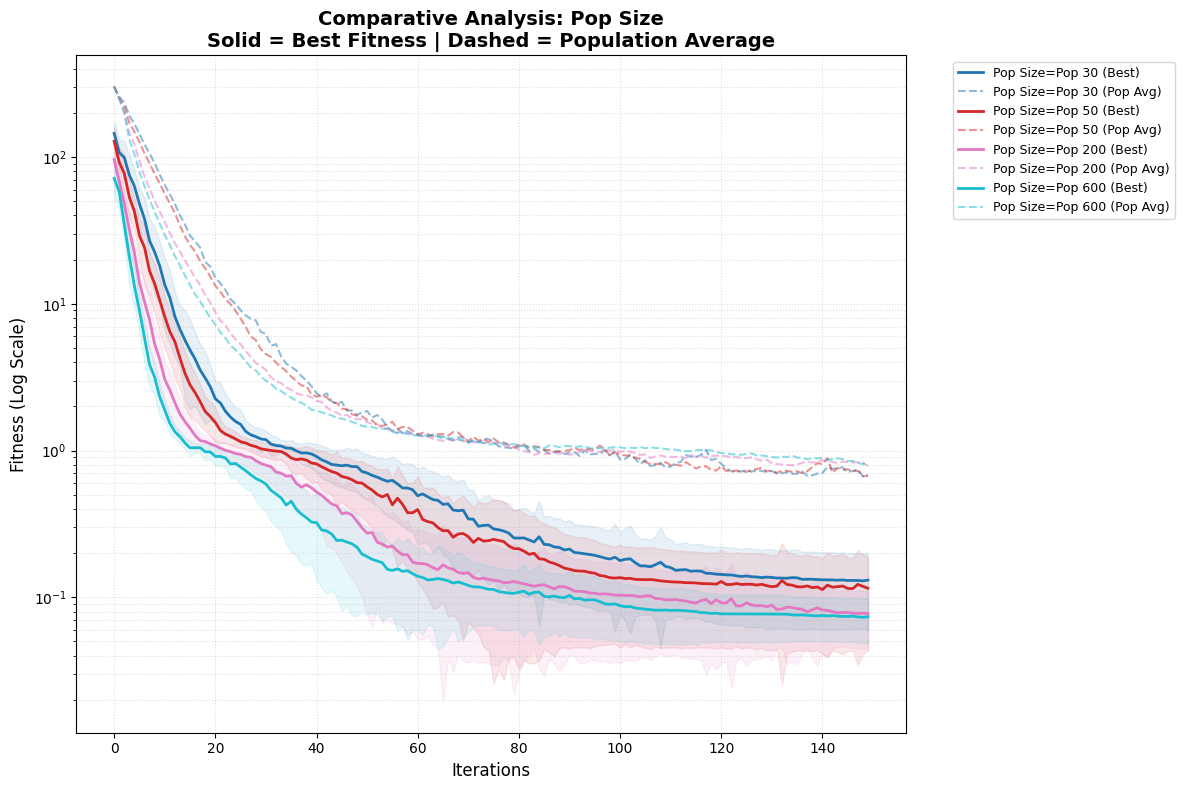

In [ ]:
dimensions = 10
lower_bound = [-600] * dimensions 
upper_bound = [600] * dimensions
rounds_sweep = 30
def_w = 0.4
def_c1 = 2.5
def_c2 = 1.5
def_iter = 150


print(f"Initializing Parameter Sweep - Griewank {dimensions}D, w = {def_w}, c1 = {def_c1}, c2 = {def_c2}...")
pop_configs =  [30, 50, 200, 600]


master_results = {} 
results_pso = []

for pop in pop_configs:
    print(f"\nTrying PSO with population {pop}")
    start = time.time()
    
    
    result = run_experiment(
        'PSO', griewank, dimensions, lower_bound, upper_bound, 
        {'w': def_w, 'c1': def_c1, 'c2': def_c2}, 
        rounds_sweep, def_iter, pop, 
        title_suffix=f"Population size: {pop}"
    )
    
    results_pso.append({
        'Alg': 'PSO', 'population': pop, 
        'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']
    })
    
    
    label = f"Pop {pop}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso2 = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - GRIEWANK " + str(dimensions) + "D")
print("="*70)
print(df_pso2.to_string(index=False))

plot_final_comparison(master_results, var_name="Pop Size", filename="comparativa_final_pso_griewank_pop.png")

### **Testing on Iterations**

Initializing Parameter Sweep - Griewank 10D, w = 0.4, c1 = 2.5, c2 = 1.5...

Trying PSO with iterations 150


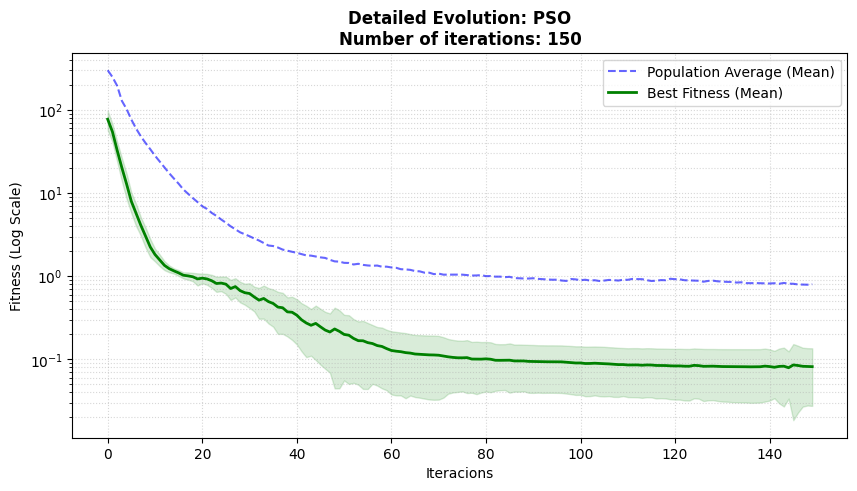

  -> Made in 15.55s | Avg: 0.0781 | Min: 0.0323 | Std: 0.0435

Trying PSO with iterations 300


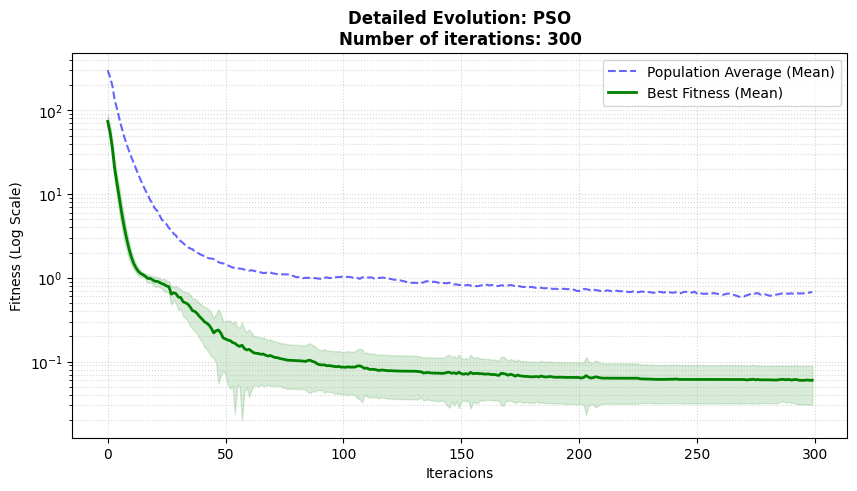

  -> Made in 31.02s | Avg: 0.0593 | Min: 0.0148 | Std: 0.0287

Trying PSO with iterations 600


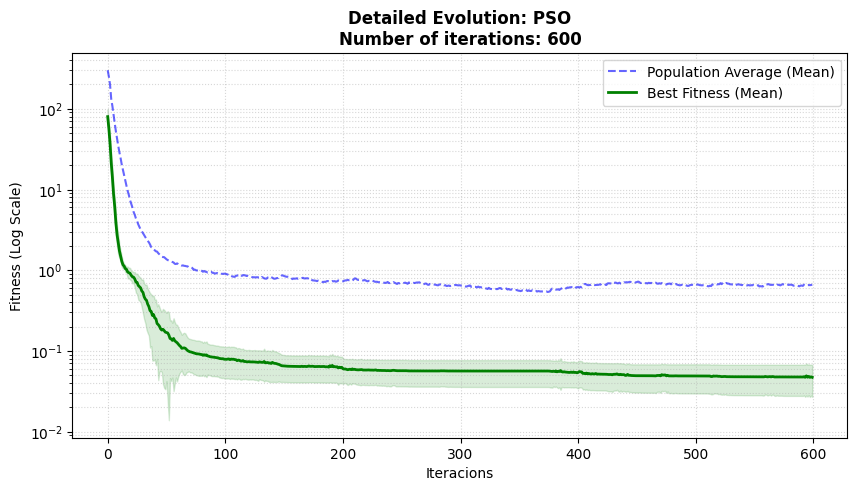

  -> Made in 62.05s | Avg: 0.0471 | Min: 0.0148 | Std: 0.0202

 RESULTS PSO - GRIEWANK 10D
Alg  iterations  Avg Fit  Min Fit  Std Dev
PSO         150 0.078052 0.032296 0.043496
PSO         300 0.059282 0.014780 0.028738
PSO         600 0.047147 0.014772 0.020200


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


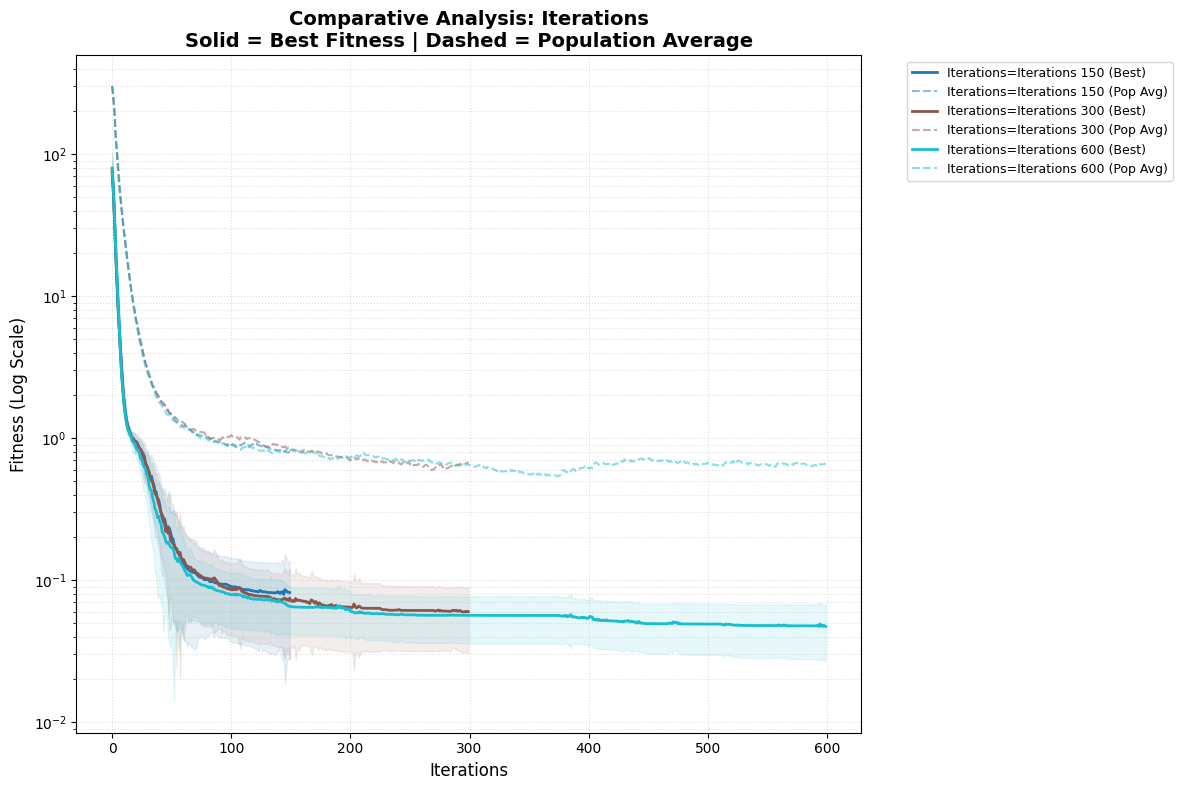

In [ ]:

dimensions = 10
lower_bound = [-600] * dimensions 
upper_bound = [600] * dimensions
rounds_sweep = 30
def_w = 0.4
def_c1 = 2.5
def_c2 = 1.5
def_pop = 600


print(f"Initializing Parameter Sweep - Griewank {dimensions}D, w = {def_w}, c1 = {def_c1}, c2 = {def_c2}...")
iter_configs =  [150, 300, 600]


master_results = {} 
results_pso = []

for iter in iter_configs:
    print(f"\nTrying PSO with iterations {iter}")
    start = time.time()
    
    
    result = run_experiment(
        'PSO', griewank, dimensions, lower_bound, upper_bound, 
        {'w': def_w, 'c1': def_c1, 'c2': def_c2}, 
        rounds_sweep, iter, def_pop, 
        title_suffix=f"Number of iterations: {iter}"
    )
    
    results_pso.append({
        'Alg': 'PSO', 'iterations': iter, 
        'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']
    })
    
    
    label = f"Iterations {iter}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso2 = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - GRIEWANK " + str(dimensions) + "D")
print("="*70)
print(df_pso2.to_string(index=False))

plot_final_comparison(master_results, var_name="Iterations", filename="comparativa_final_pso_griewank_iterations.png")

## **Rosenbrock function**

### **Testing on w, c1 & c2**

Initializing Parameter Sweep - Rosenbrock 10D...

Trying PSO with these parameters -> w: 0.8, c1: 0.5, c2: 0.5...


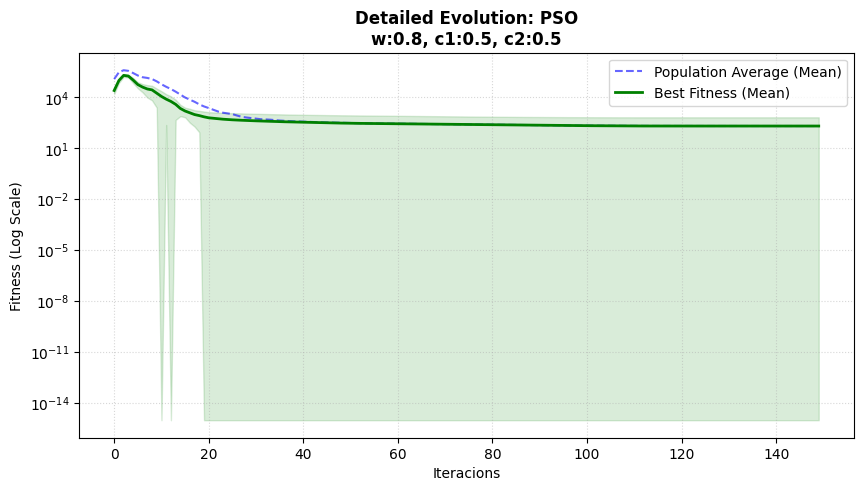

  -> Made in 1.34s | Avg: 203.8289 | Min: 1.8360 | Std: 461.0200

Trying PSO with these parameters -> w: 0.9, c1: 1.5, c2: 1.5...


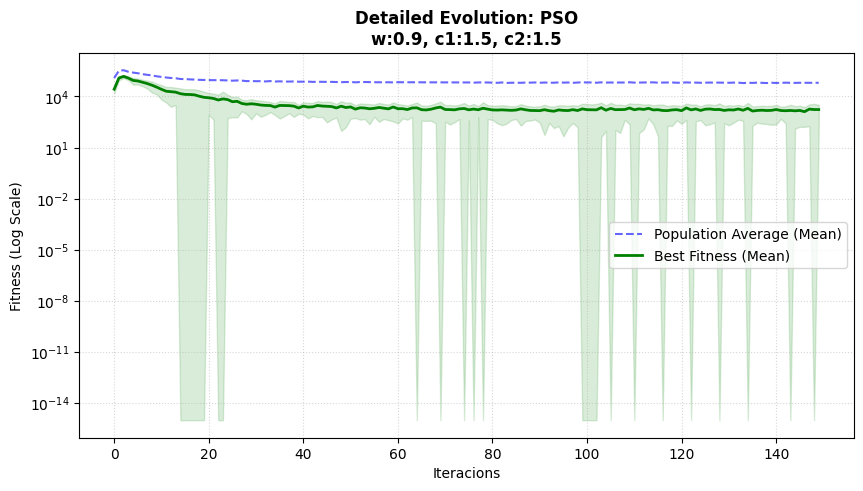

  -> Made in 1.29s | Avg: 654.8423 | Min: 64.6895 | Std: 911.6270

Trying PSO with these parameters -> w: 0.4, c1: 2.0, c2: 2.0...


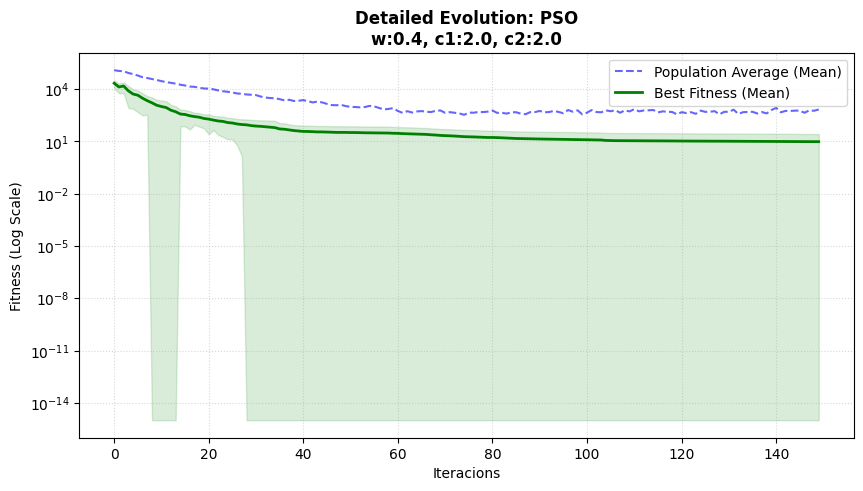

  -> Made in 1.46s | Avg: 9.6367 | Min: 0.1872 | Std: 16.7232

Trying PSO with these parameters -> w: 0.9, c1: 0.1, c2: 3.9...


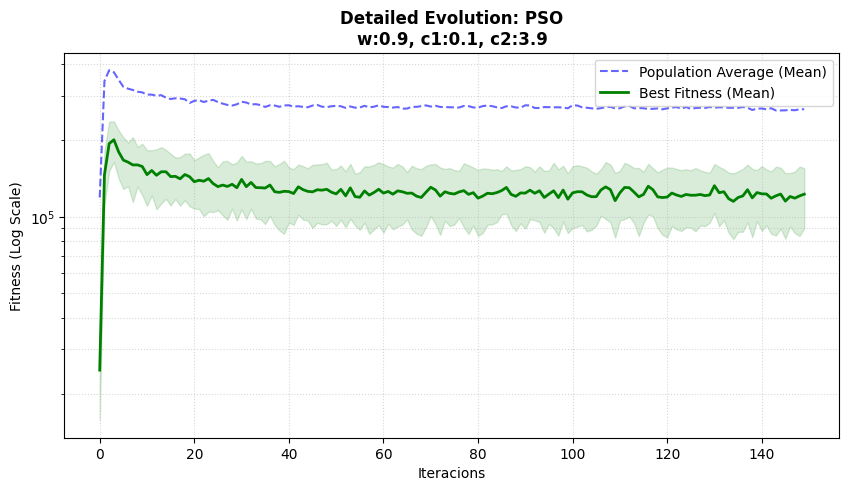

  -> Made in 1.30s | Avg: 90075.1296 | Min: 48315.5873 | Std: 33616.7734

 RESULTS PSO - ROSENBROCK 10D
Alg   w  c1  c2      Avg Fit      Min Fit      Std Dev
PSO 0.8 0.5 0.5   203.828906     1.835968   461.019983
PSO 0.9 1.5 1.5   654.842261    64.689540   911.626978
PSO 0.4 2.0 2.0     9.636683     0.187247    16.723237
PSO 0.9 0.1 3.9 90075.129604 48315.587328 33616.773437


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


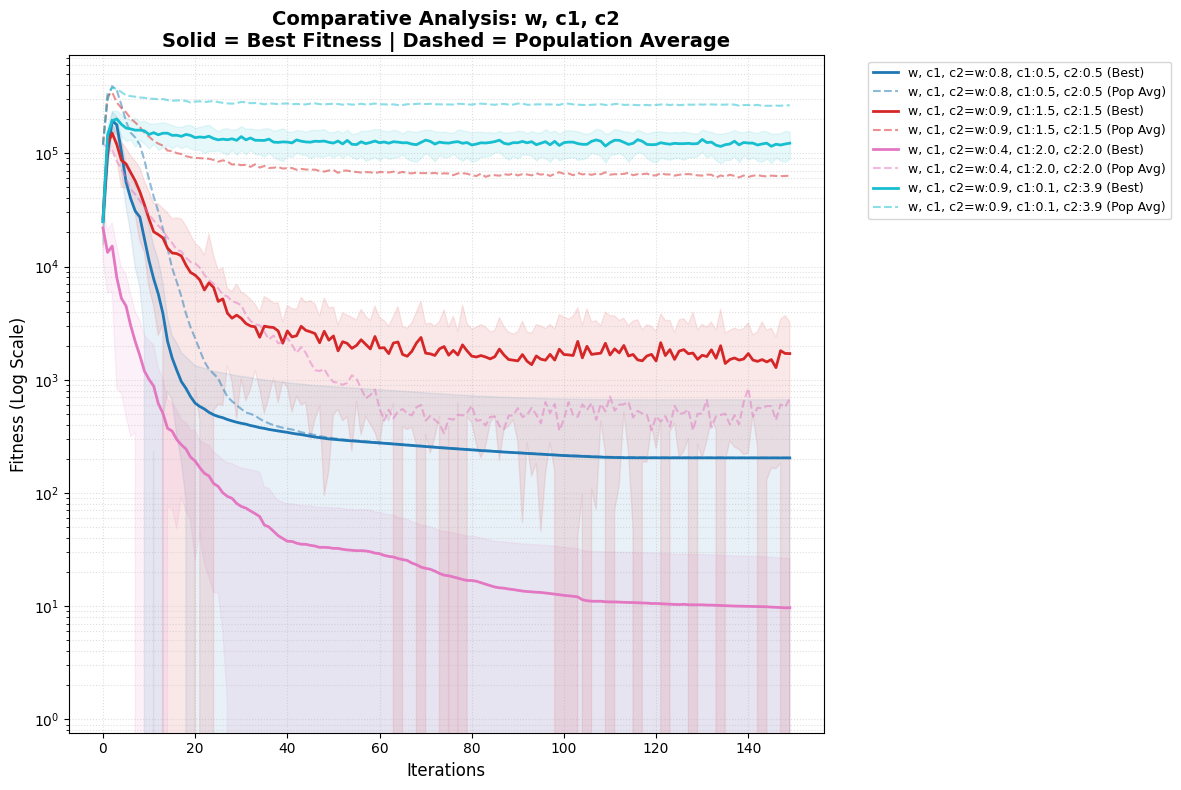

In [ ]:

dimensions = 10
lower_bound = [-5] * dimensions 
upper_bound = [5] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150

results_pso = []
master_results = {}

print(f"Initializing Parameter Sweep - Rosenbrock {dimensions}D...")

# Escombrat de Inèrcia (w) i Factors (c1, c2)
# Ens assegurem de complir Engelbrecht: c1 + c2 <= 4
configs = [
    {'w': 0.8, 'c1': 0.5, 'c2': 0.5}, # Exploració moderada
    {'w': 0.9, 'c1': 1.5, 'c2': 1.5}, # Exploració alta (c1+c2 = 3)
    {'w': 0.4, 'c1': 2.0, 'c2': 2.0}, # Convergència ràpida (c1+c2 = 4)
    {'w': 0.9, 'c1': 0.1, 'c2': 3.9}  # Molt social, poc cognitiu (c1+c2 = 4)
]

for cfg in configs:
    w, c1, c2 = cfg['w'], cfg['c1'], cfg['c2']
    print(f"\nTrying PSO with these parameters -> w: {w}, c1: {c1}, c2: {c2}...")
    start = time.time()
    result = run_experiment('PSO', rosenbrock, dimensions, lower_bound, upper_bound, cfg, rounds_sweep, def_iter, def_pop, title_suffix=f"w:{w}, c1:{c1}, c2:{c2}")
    results_pso.append({'Alg': 'PSO', 'w': w, 'c1': c1, 'c2': c2, 'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']})
    label = f"w:{w}, c1:{c1}, c2:{c2}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - ROSENBROCK " + str(dimensions) + "D")
print("="*70)
print(df_pso.to_string(index=False))

plot_final_comparison(master_results, var_name="w, c1, c2", filename="comparativa_final_pso_rosenbrock_w.png")

Initializing Parameter Sweep - Rosenbrock 10D...

Trying PSO with these parameters -> w: 0.4, c1: 2.0, c2: 2.0...


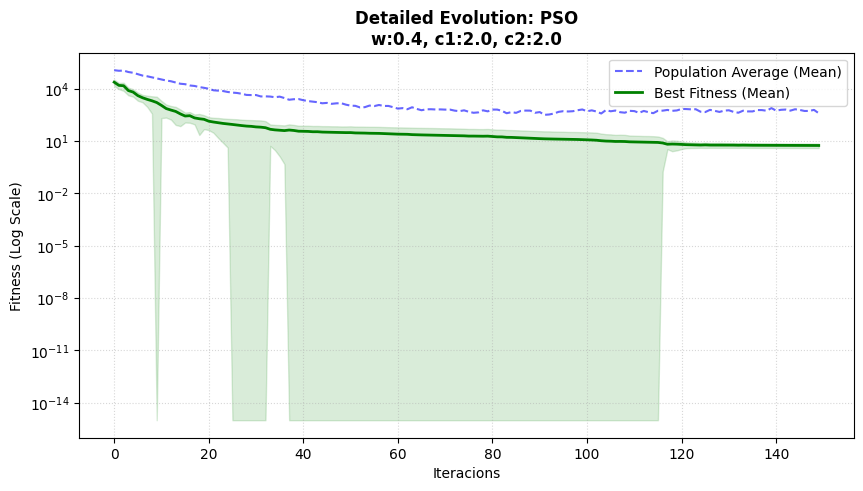

  -> Made in 1.32s | Avg: 5.6527 | Min: 1.8360 | Std: 1.6453

Trying PSO with these parameters -> w: 0.5, c1: 2.0, c2: 2.0...


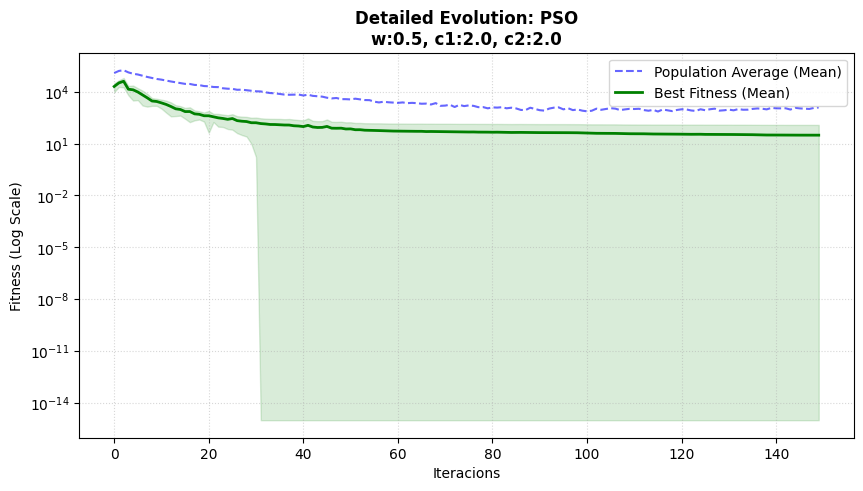

  -> Made in 1.32s | Avg: 30.5412 | Min: 1.6823 | Std: 89.5611

Trying PSO with these parameters -> w: 0.3, c1: 2.0, c2: 2.0...


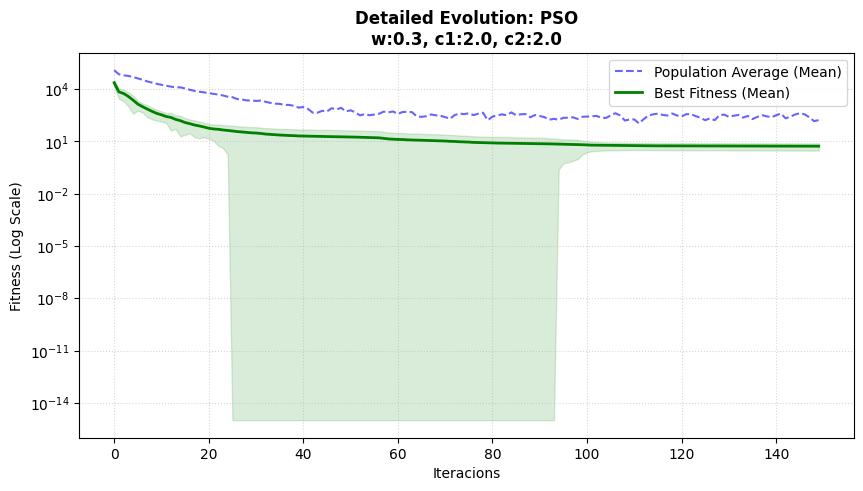

  -> Made in 1.41s | Avg: 5.2990 | Min: 0.1146 | Std: 2.3391

Trying PSO with these parameters -> w: 0.4, c1: 1.5, c2: 2.5...


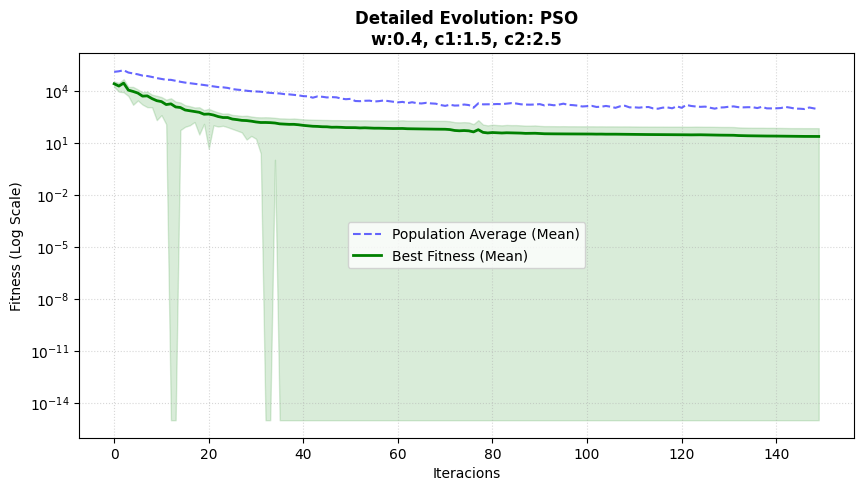

  -> Made in 1.27s | Avg: 22.8689 | Min: 0.2542 | Std: 45.7689

Trying PSO with these parameters -> w: 0.4, c1: 2.5, c2: 1.5...


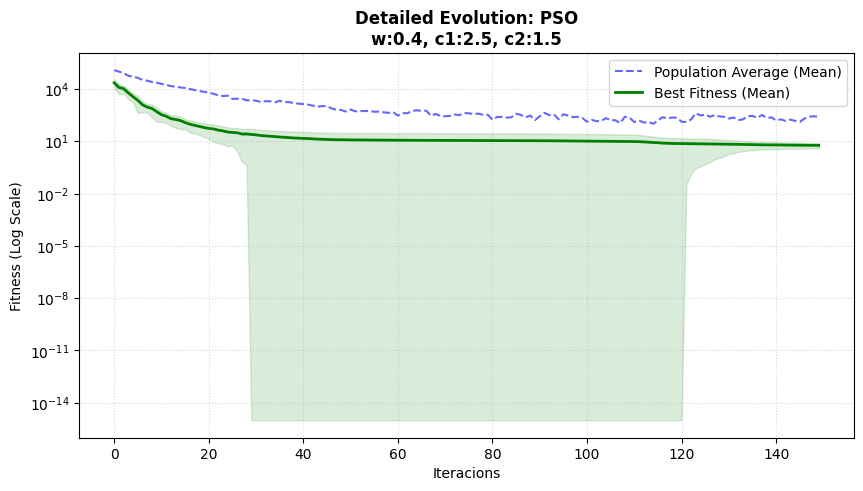

  -> Made in 1.40s | Avg: 5.7972 | Min: 3.1614 | Std: 1.8582

Trying PSO with these parameters -> w: 0.5, c1: 1.5, c2: 1.5...


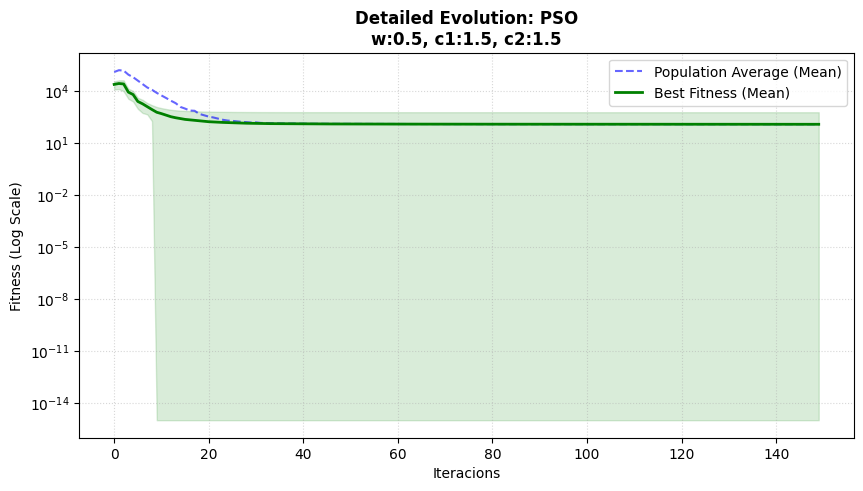

  -> Made in 1.38s | Avg: 114.7998 | Min: 0.2700 | Std: 454.2505

 RESULTS PSO - ROSENBROCK 10D
Alg   w  c1  c2    Avg Fit  Min Fit    Std Dev
PSO 0.4 2.0 2.0   5.652720 1.835969   1.645278
PSO 0.5 2.0 2.0  30.541155 1.682337  89.561074
PSO 0.3 2.0 2.0   5.298981 0.114563   2.339122
PSO 0.4 1.5 2.5  22.868898 0.254218  45.768945
PSO 0.4 2.5 1.5   5.797184 3.161424   1.858188
PSO 0.5 1.5 1.5 114.799815 0.269950 454.250480


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


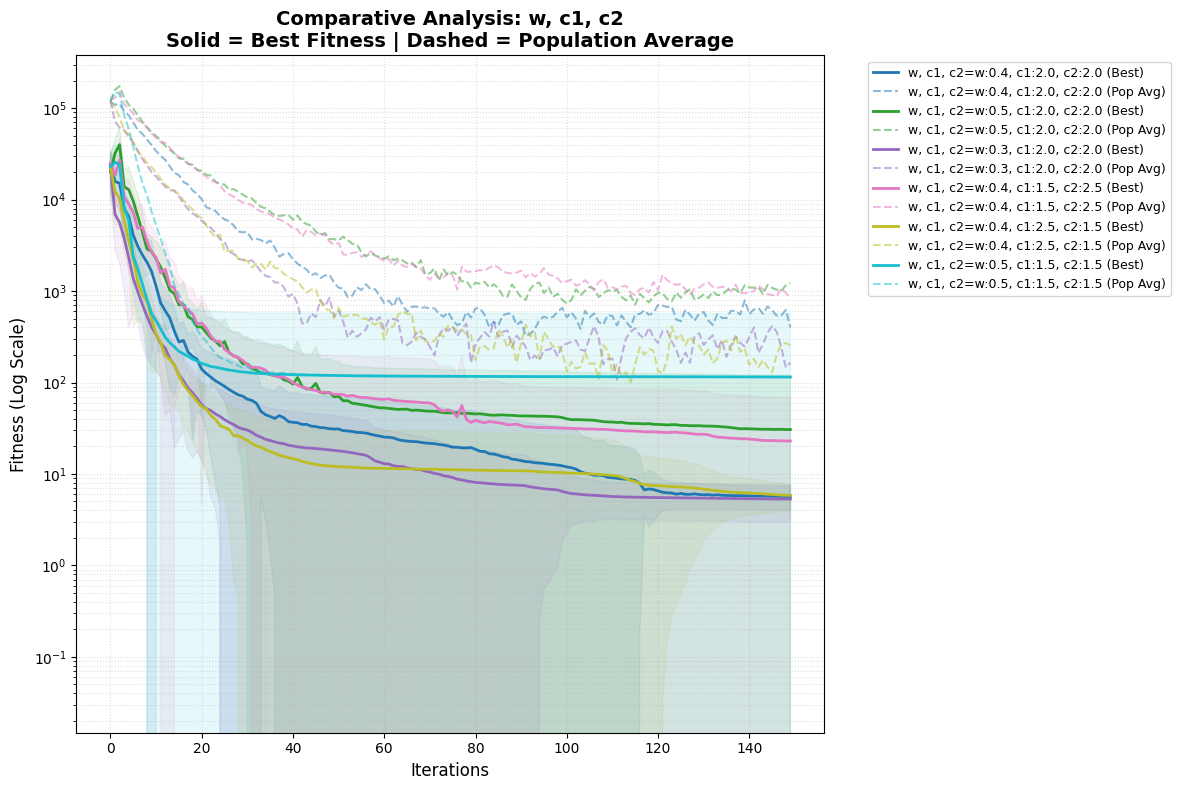

In [ ]:

dimensions = 10
lower_bound = [-5] * dimensions 
upper_bound = [5] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150

results_pso = []
master_results = {}

print(f"Initializing Parameter Sweep - Rosenbrock {dimensions}D...")


configs = [
    {'w': 0.4, 'c1': 2.0, 'c2': 2.0},  
    {'w': 0.5, 'c1': 2.0, 'c2': 2.0}, 
    {'w': 0.3, 'c1': 2.0, 'c2': 2.0}, 
    {'w': 0.4, 'c1': 1.5, 'c2': 2.5},  
    {'w': 0.4, 'c1': 2.5, 'c2': 1.5},  
    {'w': 0.5, 'c1': 1.5, 'c2': 1.5},  
]

for cfg in configs:
    w, c1, c2 = cfg['w'], cfg['c1'], cfg['c2']
    print(f"\nTrying PSO with these parameters -> w: {w}, c1: {c1}, c2: {c2}...")
    start = time.time()
    result = run_experiment('PSO', rosenbrock, dimensions, lower_bound, upper_bound, cfg, rounds_sweep, def_iter, def_pop, title_suffix=f"w:{w}, c1:{c1}, c2:{c2}")
    results_pso.append({'Alg': 'PSO', 'w': w, 'c1': c1, 'c2': c2, 'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']})
    label = f"w:{w}, c1:{c1}, c2:{c2}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - ROSENBROCK " + str(dimensions) + "D")
print("="*70)
print(df_pso.to_string(index=False))

plot_final_comparison(master_results, var_name="w, c1, c2", filename="comparativa_final_pso_rosenbrock_w_expanded.png")

### **Testing on Population**

Initializing Parameter Sweep - Rosenbrock 10D, w = 0.3, c1 = 2.0, c2 = 2.0...

Trying PSO with population 30


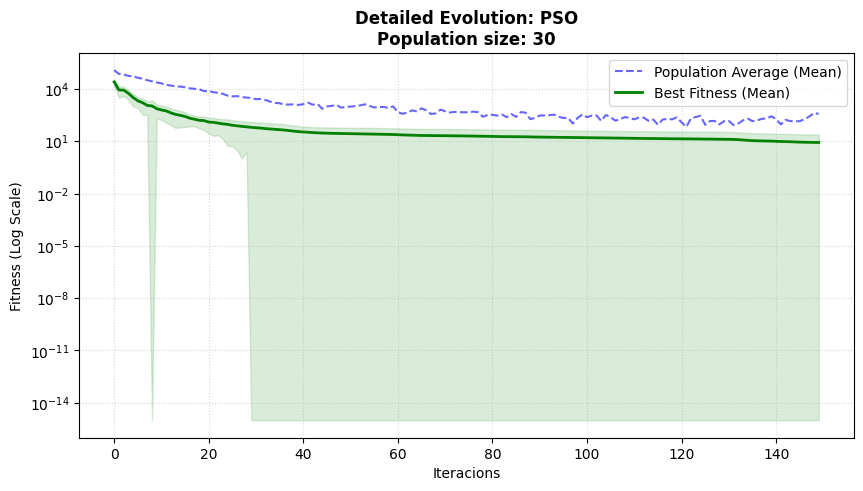

  -> Made in 1.03s | Avg: 8.4152 | Min: 0.0065 | Std: 15.9785

Trying PSO with population 50


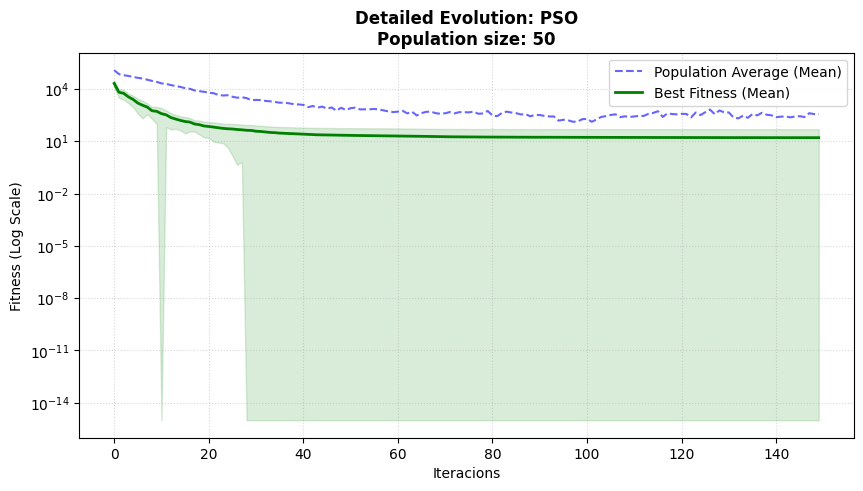

  -> Made in 1.29s | Avg: 15.8602 | Min: 0.2141 | Std: 32.6034

Trying PSO with population 200


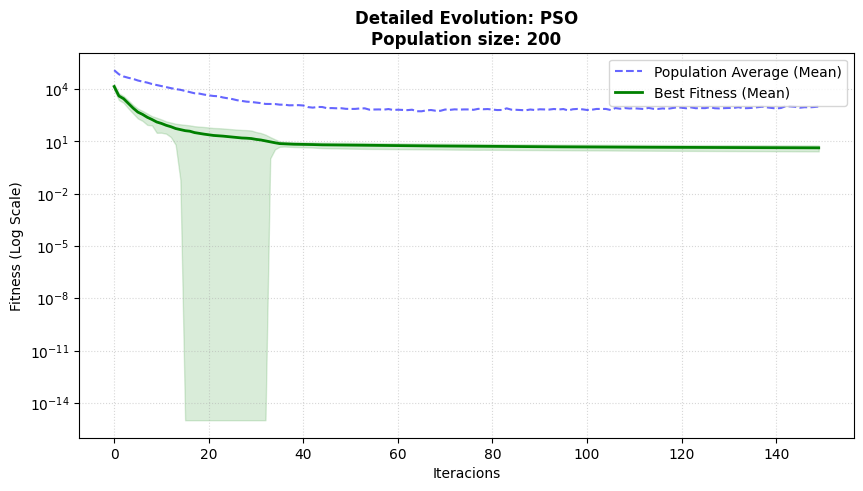

  -> Made in 4.49s | Avg: 4.2444 | Min: 0.0763 | Std: 1.5831

Trying PSO with population 600


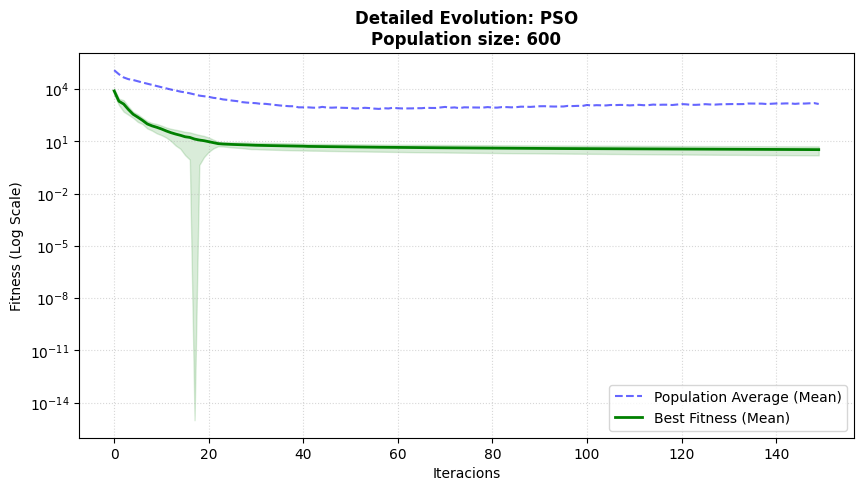

  -> Made in 12.81s | Avg: 3.3257 | Min: 0.0150 | Std: 1.7651

 RESULTS PSO - ROSENBROCK 10D
Alg  population   Avg Fit  Min Fit   Std Dev
PSO          30  8.415171 0.006544 15.978480
PSO          50 15.860228 0.214079 32.603365
PSO         200  4.244384 0.076317  1.583131
PSO         600  3.325720 0.015000  1.765081


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


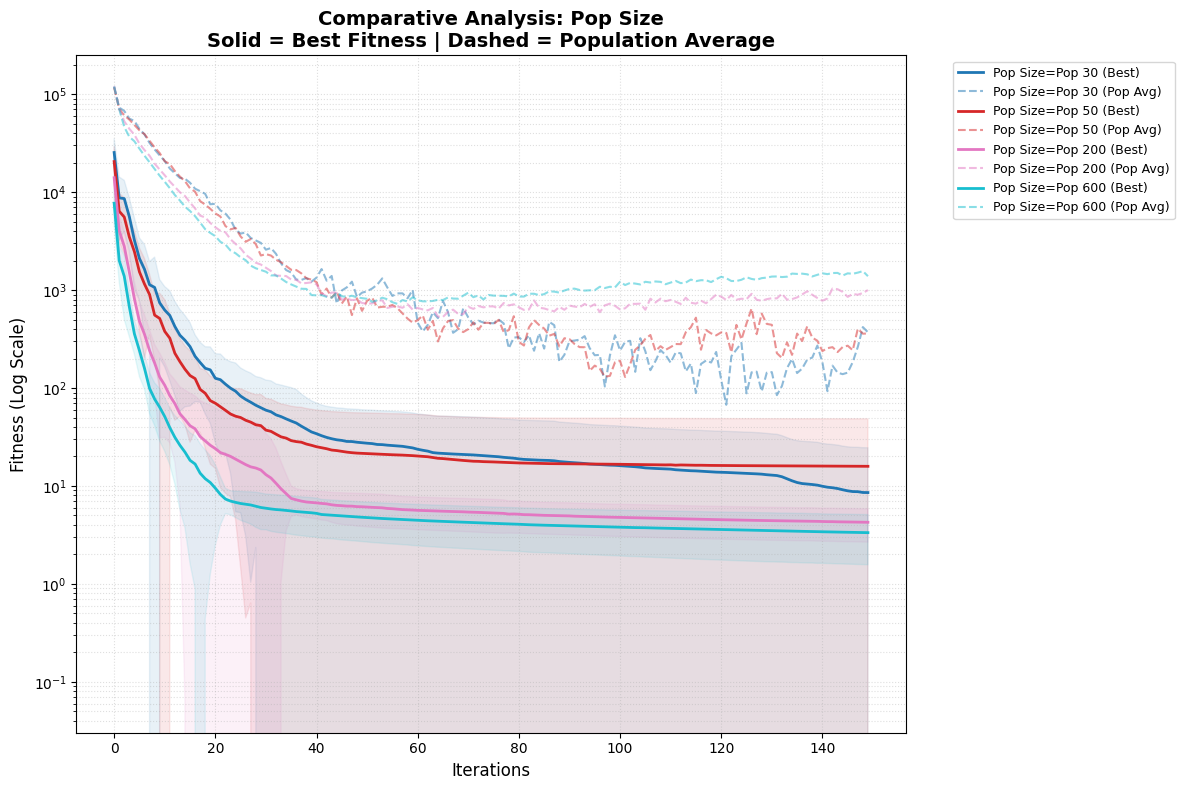

In [ ]:
# Configuració bàsica
dimensions = 10
lower_bound = [-5] * dimensions 
upper_bound = [5] * dimensions
rounds_sweep = 30
def_w = 0.3
def_c1 = 2.0
def_c2 = 2.0
def_iter = 150


print(f"Initializing Parameter Sweep - Rosenbrock {dimensions}D, w = {def_w}, c1 = {def_c1}, c2 = {def_c2}...")
pop_configs =  [30, 50, 200, 600]


master_results = {} 
results_pso = []

for pop in pop_configs:
    print(f"\nTrying PSO with population {pop}")
    start = time.time()
    
    # Canviem def_pop per pop, i afegim el sufix per al títol
    result = run_experiment(
        'PSO', rosenbrock, dimensions, lower_bound, upper_bound, 
        {'w': def_w, 'c1': def_c1, 'c2': def_c2}, 
        rounds_sweep, def_iter, pop, 
        title_suffix=f"Population size: {pop}"
    )
    
    results_pso.append({
        'Alg': 'PSO', 'population': pop, 
        'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']
    })
    
    # Guardem per al gràfic conjunt
    label = f"Pop {pop}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso2 = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - ROSENBROCK " + str(dimensions) + "D")
print("="*70)
print(df_pso2.to_string(index=False))
# Gràfic final comparatiu
plot_final_comparison(master_results, var_name="Pop Size", filename="comparativa_final_pso_rosenbrock_pop.png")

### **Testing on Iterations**

Initializing Parameter Sweep - Rosenbrock 10D, w = 0.3, c1 = 2.0, c2 = 2.0...

Trying PSO with iterations 150


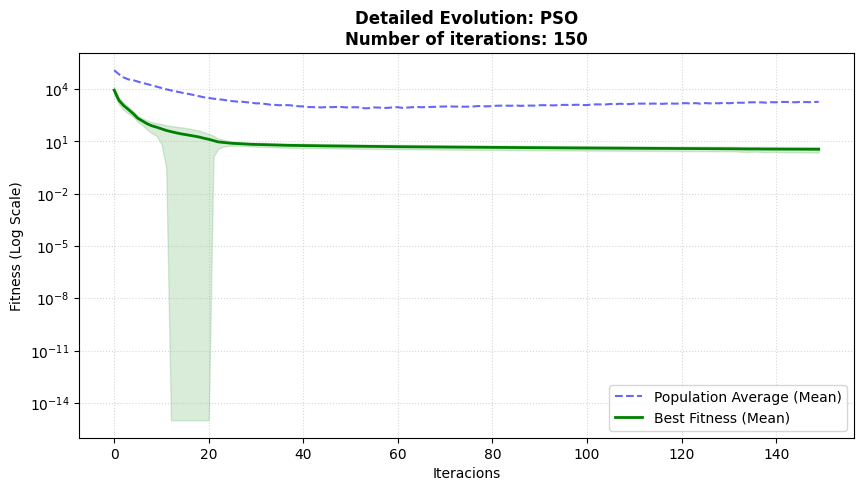

  -> Made in 12.80s | Avg: 3.4921 | Min: 0.0575 | Std: 1.2086

Trying PSO with iterations 300


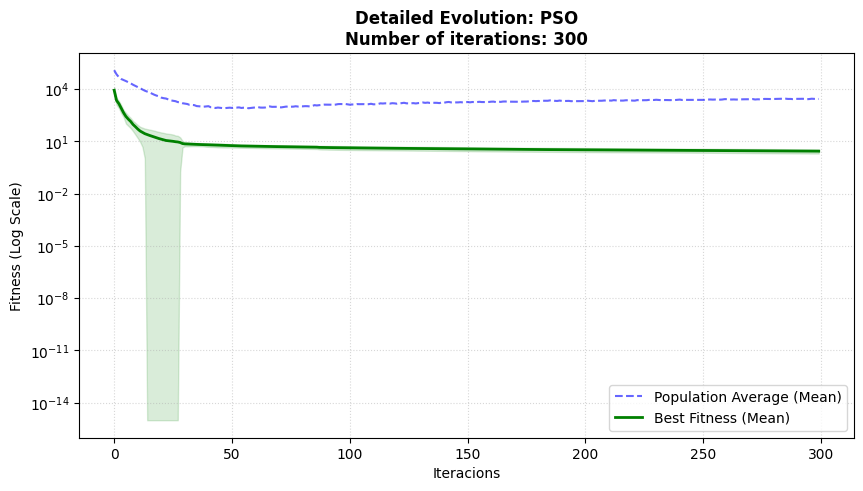

  -> Made in 24.97s | Avg: 2.7184 | Min: 0.5874 | Std: 0.7405

Trying PSO with iterations 600


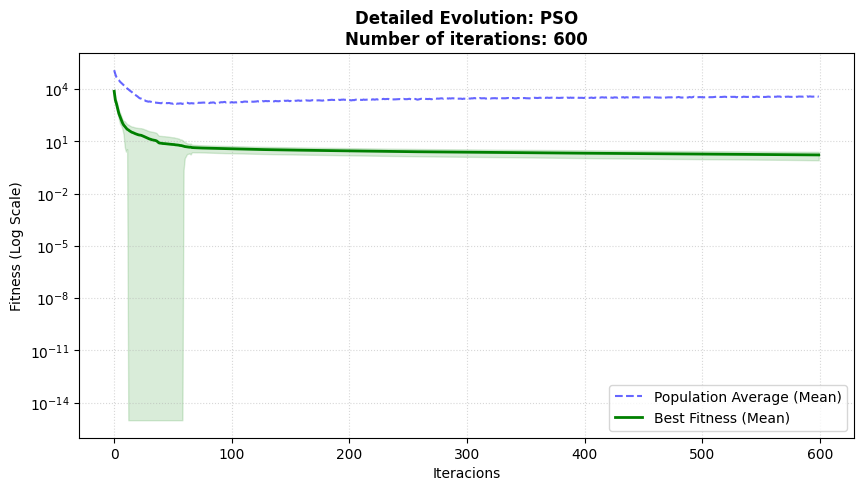

  -> Made in 50.73s | Avg: 1.6485 | Min: 0.0002 | Std: 0.8349

 RESULTS PSO - ROSENBROCK 10D
Alg  iterations  Avg Fit  Min Fit  Std Dev
PSO         150 3.492052 0.057507 1.208589
PSO         300 2.718393 0.587443 0.740450
PSO         600 1.648496 0.000239 0.834917


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


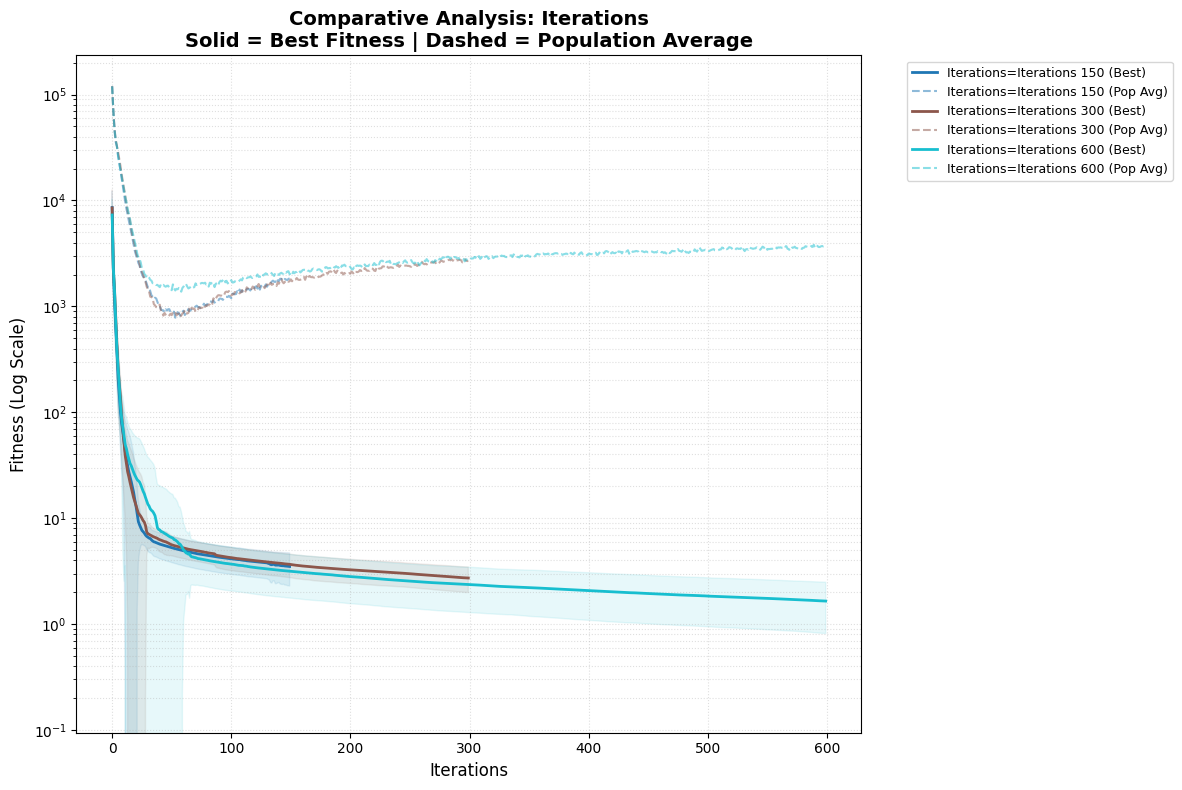

In [ ]:
dimensions = 10
lower_bound = [-5] * dimensions 
upper_bound = [5] * dimensions
rounds_sweep = 30
def_w = 0.3
def_c1 = 2.0
def_c2 = 2.0
def_pop = 600


print(f"Initializing Parameter Sweep - Rosenbrock {dimensions}D, w = {def_w}, c1 = {def_c1}, c2 = {def_c2}...")
iter_configs =  [150, 300, 600]


master_results = {} 
results_pso = []

for iter in iter_configs:
    print(f"\nTrying PSO with iterations {iter}")
    start = time.time()
    
    # Canviem def_pop per pop, i afegim el sufix per al títol
    result = run_experiment(
        'PSO', rosenbrock, dimensions, lower_bound, upper_bound, 
        {'w': def_w, 'c1': def_c1, 'c2': def_c2}, 
        rounds_sweep, iter, def_pop, 
        title_suffix=f"Number of iterations: {iter}"
    )
    
    results_pso.append({
        'Alg': 'PSO', 'iterations': iter, 
        'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']
    })
    
    # Guardem per al gràfic conjunt
    label = f"Iterations {iter}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso2 = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - ROSENBROCK " + str(dimensions) + "D")
print("="*70)
print(df_pso2.to_string(index=False))
# Gràfic final comparatiu
plot_final_comparison(master_results, var_name="Iterations", filename="comparativa_final_pso_rosenbrock_iterations.png")

# **Differential Evolution**

## **Griewank function**

### **Testing on F & CR**

Initializing Parameter Sweep - DE on Griewank 10D...

Trying DE with -> F: 0.5, CR: 0.3... 

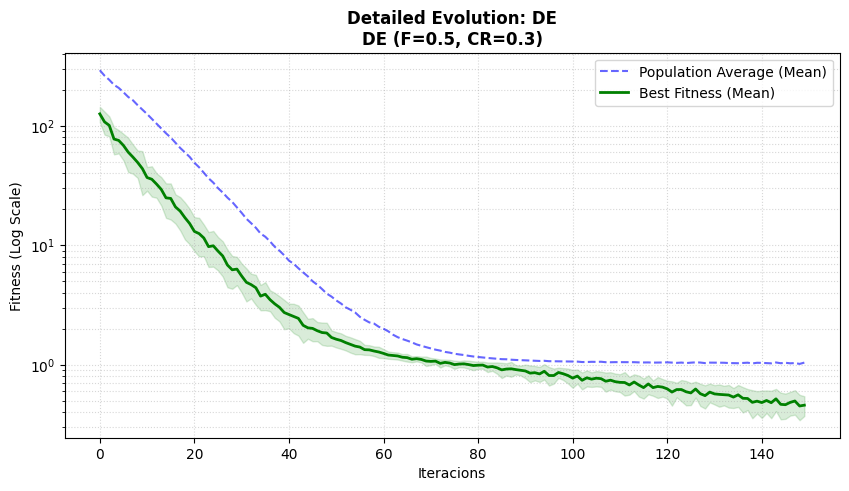

DONE! (2.68s) | Avg: 0.3188 | Min: 0.1775 | Std: 0.0614

Trying DE with -> F: 0.7, CR: 0.5... 

KeyboardInterrupt: 

In [ ]:
# CONFIGURATION FOR DIFFERENTIAL EVOLUTION (DE)
dimensions = 10
lower_bound = [-600] * dimensions
upper_bound = [600] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150
alg_name = "DE"

results_de = []
master_results = {}

print(f"Initializing Parameter Sweep - {alg_name} on Griewank {dimensions}D...")

# DE parameter sweep: F (Mutation) and CR (Crossover)
configs = [
    {'F': 0.5, 'prob_mut': 0.3}, # Moderate mutation, low crossover
    {'F': 0.7, 'prob_mut': 0.5}, # Balanced configuration
    {'F': 0.5, 'prob_mut': 0.9}, # Moderate mutation, high crossover
    {'F': 0.9, 'prob_mut': 0.9}  # High exploration (both F and CR high)
]

for cfg in configs:
    # Extract F and CR from the current dictionary
    f_val, cr_val = cfg['F'], cfg['prob_mut']
    print(f"\nTrying {alg_name} with -> F: {f_val}, CR: {cr_val}...", end=" ", flush=True)
    
    start = time.time()
    
    # 1. Run the experiment using the 'DE' algorithm
    # The run_experiment function already handles 'DE' when F and CR are passed in params
    result = run_experiment(
        algo_type=alg_name,
        func=griewank,
        n_dim=dimensions,
        lb=lower_bound,
        ub=upper_bound,
        params=cfg,
        rounds=rounds_sweep,
        max_iter=def_iter,
        pop=def_pop,
        title_suffix=f"DE (F={f_val}, CR={cr_val})"
    )
    
    # 2. Store data for the final results table
    results_de.append({
        'Alg': alg_name,
        'F (Mutation)': f_val,
        'CR (Crossover)': cr_val,
        'Avg Fit': result['avg'],
        'Min Fit': result['min'],
        'Std Dev': result['std']
    })
    
    # 3. Store results for the comparative plot
    label = f"F:{f_val}, CR:{cr_val}"
    master_results[label] = result
    
    print(f"DONE! ({time.time()-start:.2f}s) | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")


df_de1 = pd.DataFrame(results_de)
print("\n" + "="*80)
print(f" RESULTS {alg_name} - GRIEWANK {dimensions}D ")
print("="*80)
print(df_de1.to_string(index=False))


plot_final_comparison(
    master_results,
    var_name="Configuration (F, CR)",
    filename="comparativa_final_de_griewank_w.png"
)


Initializing Parameter Sweep - DE on Griewank 10D...

Trying DE with -> F: 0.5, CR: 0.3... 

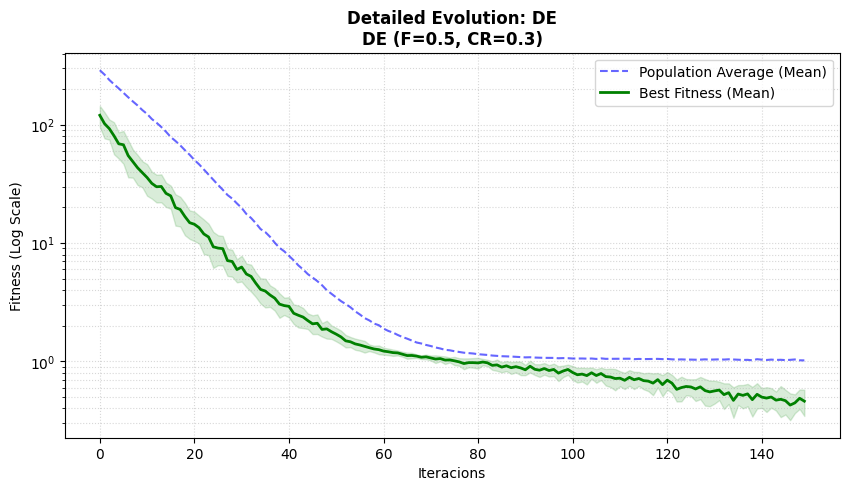

DONE! (2.65s) | Avg: 0.3050 | Min: 0.0978 | Std: 0.0901

Trying DE with -> F: 0.6, CR: 0.3... 

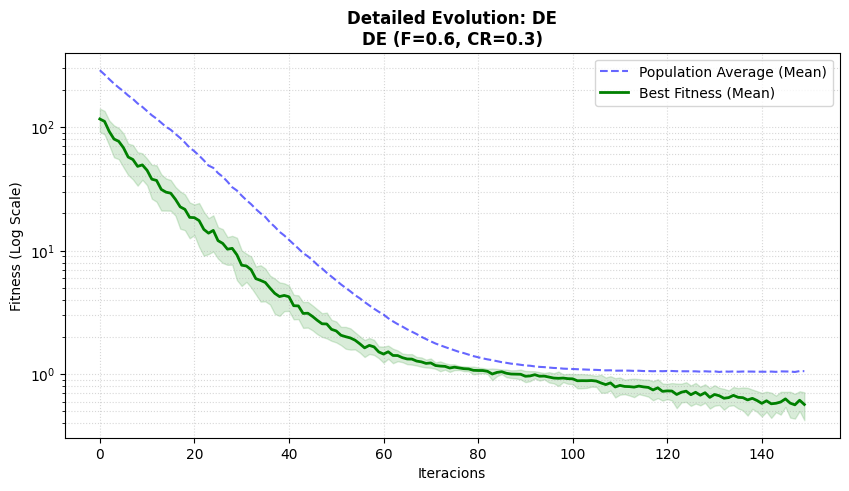

DONE! (2.54s) | Avg: 0.4061 | Min: 0.1900 | Std: 0.0926

Trying DE with -> F: 0.6, CR: 0.4... 

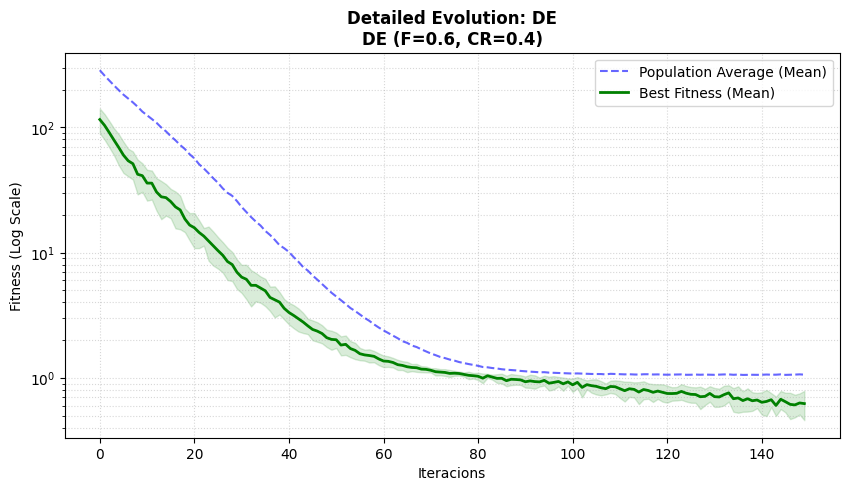

DONE! (2.66s) | Avg: 0.3882 | Min: 0.2378 | Std: 0.0897

Trying DE with -> F: 0.5, CR: 0.5... 

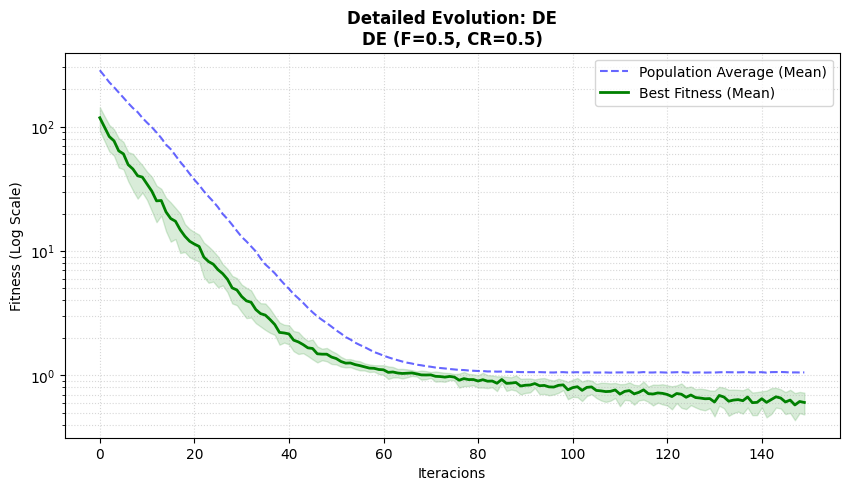

DONE! (2.58s) | Avg: 0.3735 | Min: 0.2194 | Std: 0.0789

Trying DE with -> F: 0.4, CR: 0.3... 

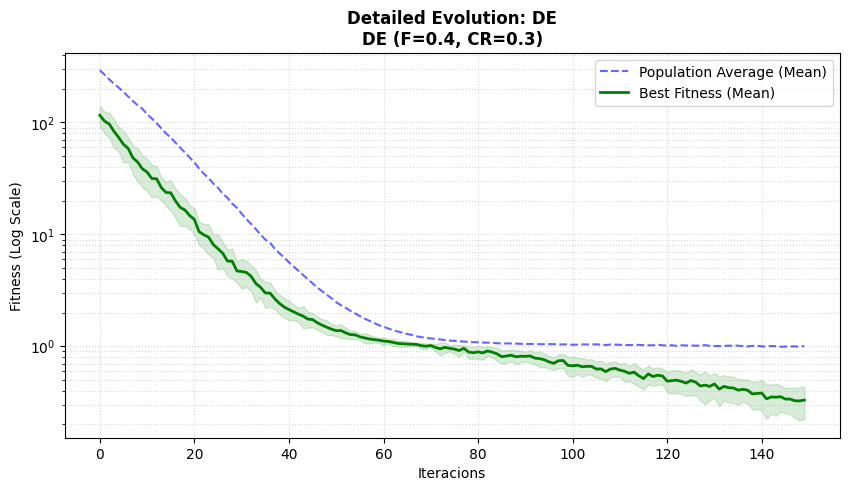

DONE! (2.56s) | Avg: 0.2270 | Min: 0.0848 | Std: 0.0687

Trying DE with -> F: 0.4, CR: 0.4... 

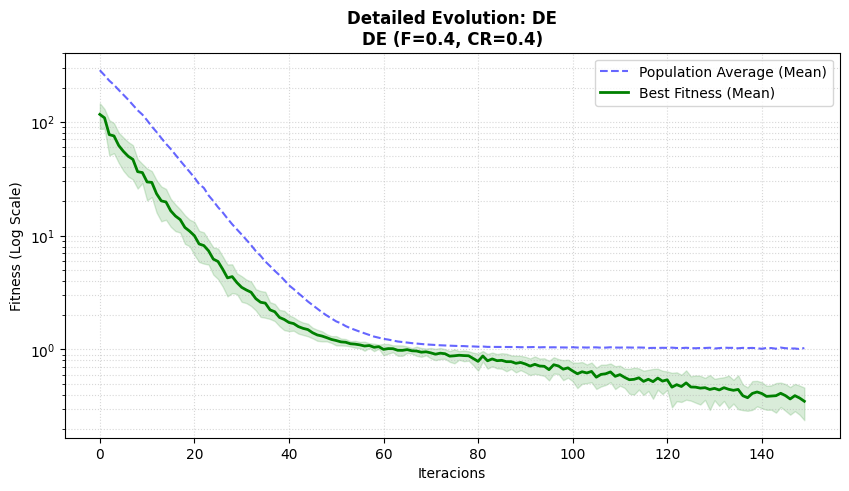

DONE! (2.60s) | Avg: 0.2271 | Min: 0.0996 | Std: 0.0612

Trying DE with -> F: 0.3, CR: 0.3... 

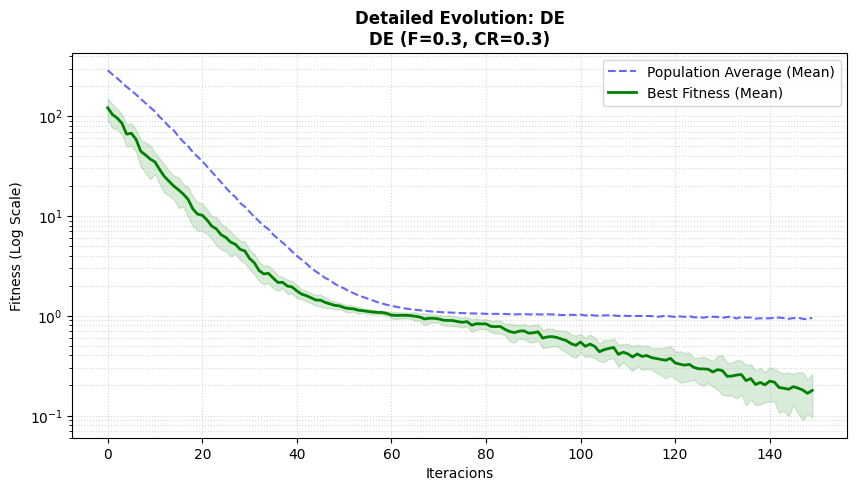

DONE! (2.72s) | Avg: 0.1163 | Min: 0.0260 | Std: 0.0514

 RESULTS DE - GRIEWANK 10D 
Alg  F (Mutation)  CR (Crossover)  Avg Fit  Min Fit  Std Dev
 DE           0.5             0.3 0.304968 0.097780 0.090108
 DE           0.6             0.3 0.406095 0.190005 0.092602
 DE           0.6             0.4 0.388210 0.237818 0.089716
 DE           0.5             0.5 0.373507 0.219400 0.078861
 DE           0.4             0.3 0.227031 0.084803 0.068724
 DE           0.4             0.4 0.227139 0.099584 0.061247
 DE           0.3             0.3 0.116312 0.026027 0.051400


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


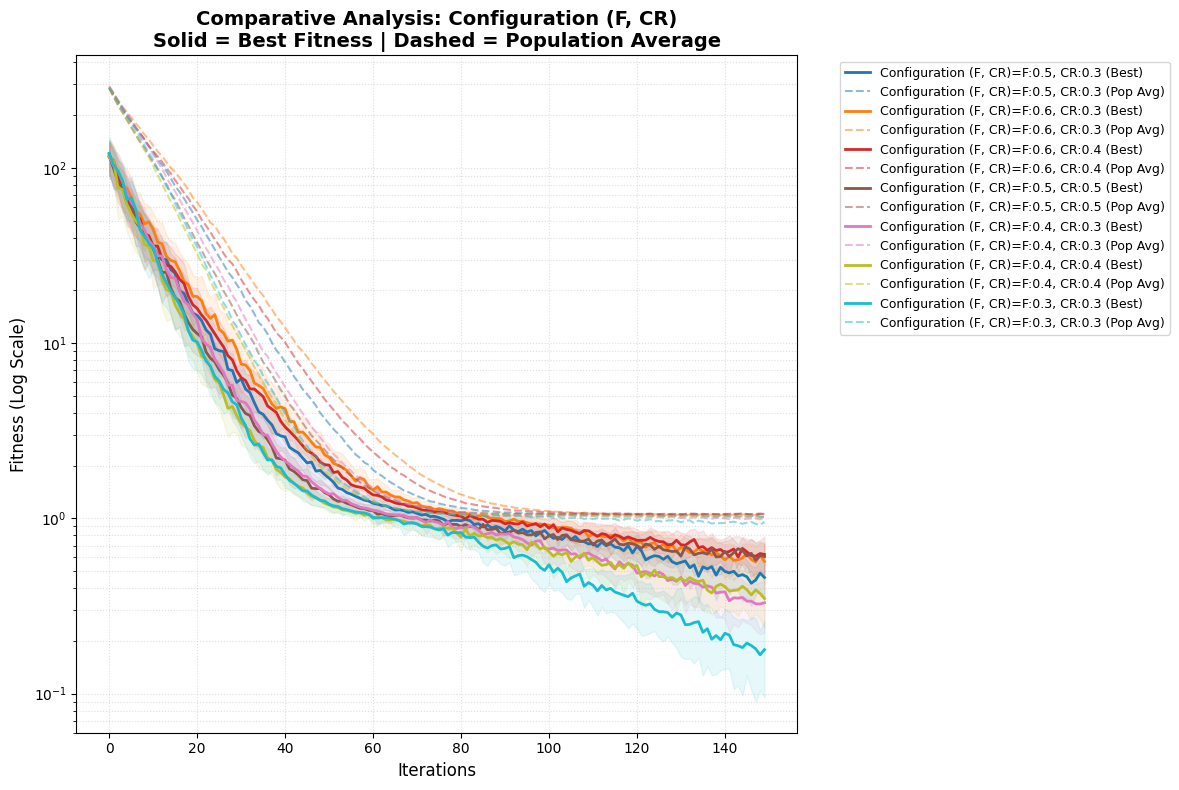

In [ ]:

dimensions = 10
lower_bound = [-600] * dimensions
upper_bound = [600] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150
alg_name = "DE"

results_de = []
master_results = {}

print(f"Initializing Parameter Sweep - {alg_name} on Griewank {dimensions}D...")


configs = [
    {'F': 0.5, 'prob_mut': 0.3}, 
    {'F': 0.6, 'prob_mut': 0.3}, 
    {'F': 0.6, 'prob_mut': 0.4}, 
    {'F': 0.5, 'prob_mut': 0.5},  
    {'F': 0.4, 'prob_mut': 0.3}, 
    {'F': 0.4, 'prob_mut': 0.4},
    {'F': 0.3, 'prob_mut': 0.3}   
]

for cfg in configs:
    f_val, cr_val = cfg['F'], cfg['prob_mut']
    print(f"\nTrying {alg_name} with -> F: {f_val}, CR: {cr_val}...", end=" ", flush=True)
    
    start = time.time()

    result = run_experiment(
        algo_type=alg_name,
        func=griewank,
        n_dim=dimensions,
        lb=lower_bound,
        ub=upper_bound,
        params=cfg,
        rounds=rounds_sweep,
        max_iter=def_iter,
        pop=def_pop,
        title_suffix=f"DE (F={f_val}, CR={cr_val})"
    )
    
    results_de.append({
        'Alg': alg_name,
        'F (Mutation)': f_val,
        'CR (Crossover)': cr_val,
        'Avg Fit': result['avg'],
        'Min Fit': result['min'],
        'Std Dev': result['std']
    })
    
    label = f"F:{f_val}, CR:{cr_val}"
    master_results[label] = result
    
    print(f"DONE! ({time.time()-start:.2f}s) | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_de1 = pd.DataFrame(results_de)
print("\n" + "="*80)
print(f" RESULTS {alg_name} - GRIEWANK {dimensions}D ")
print("="*80)
print(df_de1.to_string(index=False))


plot_final_comparison(
    master_results,
    var_name="Configuration (F, CR)",
    filename="comparativa_final_de_griewank_w_expanded.png"
)


### **Testing on Population**

Initializing Parameter Sweep - DE on Griewank 10D...

Trying DE with population 30 

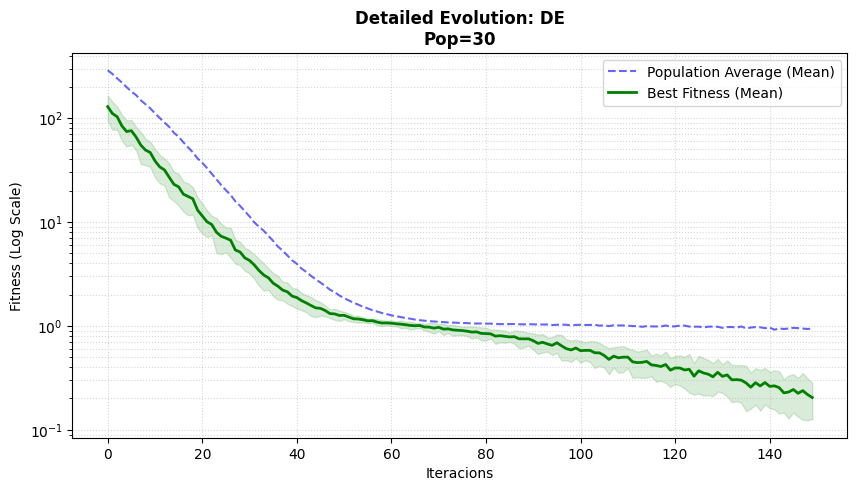

DONE! (1.74s) | Avg: 0.1427 | Min: 0.0435 | Std: 0.0604

Trying DE with population 50 

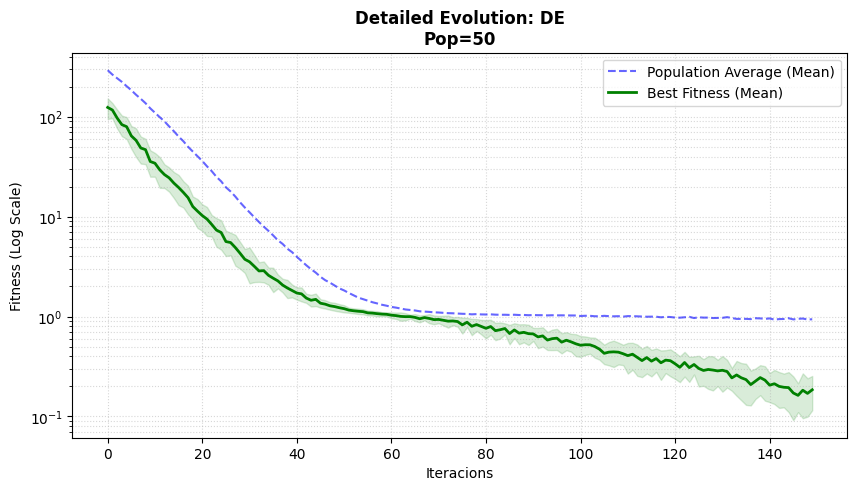

DONE! (2.64s) | Avg: 0.1236 | Min: 0.0249 | Std: 0.0482

Trying DE with population 200 

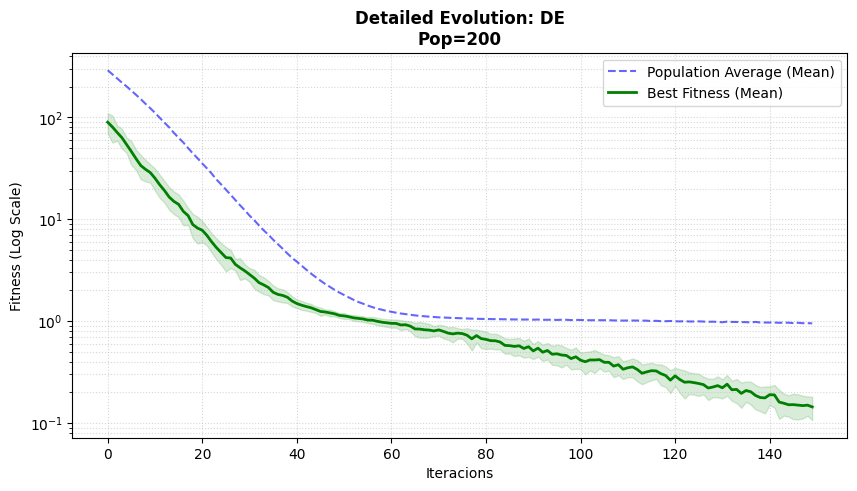

DONE! (9.45s) | Avg: 0.1036 | Min: 0.0569 | Std: 0.0207

Trying DE with population 600 

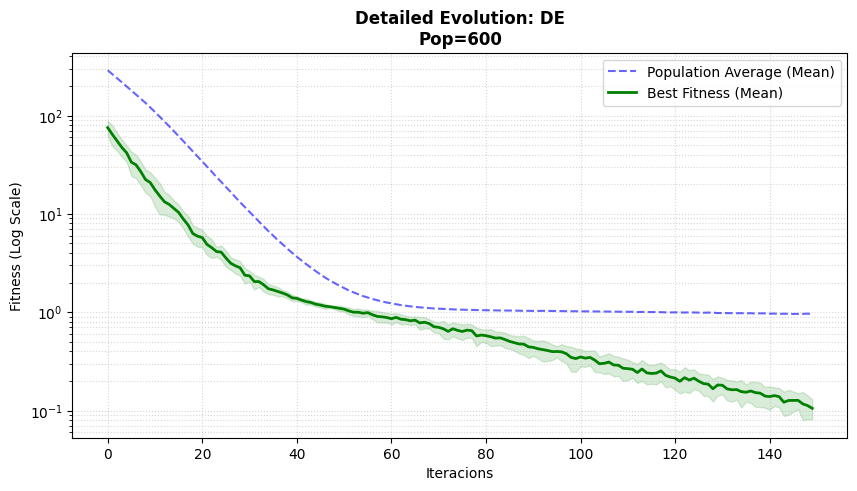

DONE! (27.20s) | Avg: 0.0825 | Min: 0.0373 | Std: 0.0193

 RESULTS DE - GRIEWANK 10D 
Alg  Population  Avg Fit  Min Fit  Std Dev
 DE          30 0.142707 0.043529 0.060412
 DE          50 0.123638 0.024928 0.048246
 DE         200 0.103649 0.056918 0.020722
 DE         600 0.082491 0.037309 0.019313


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


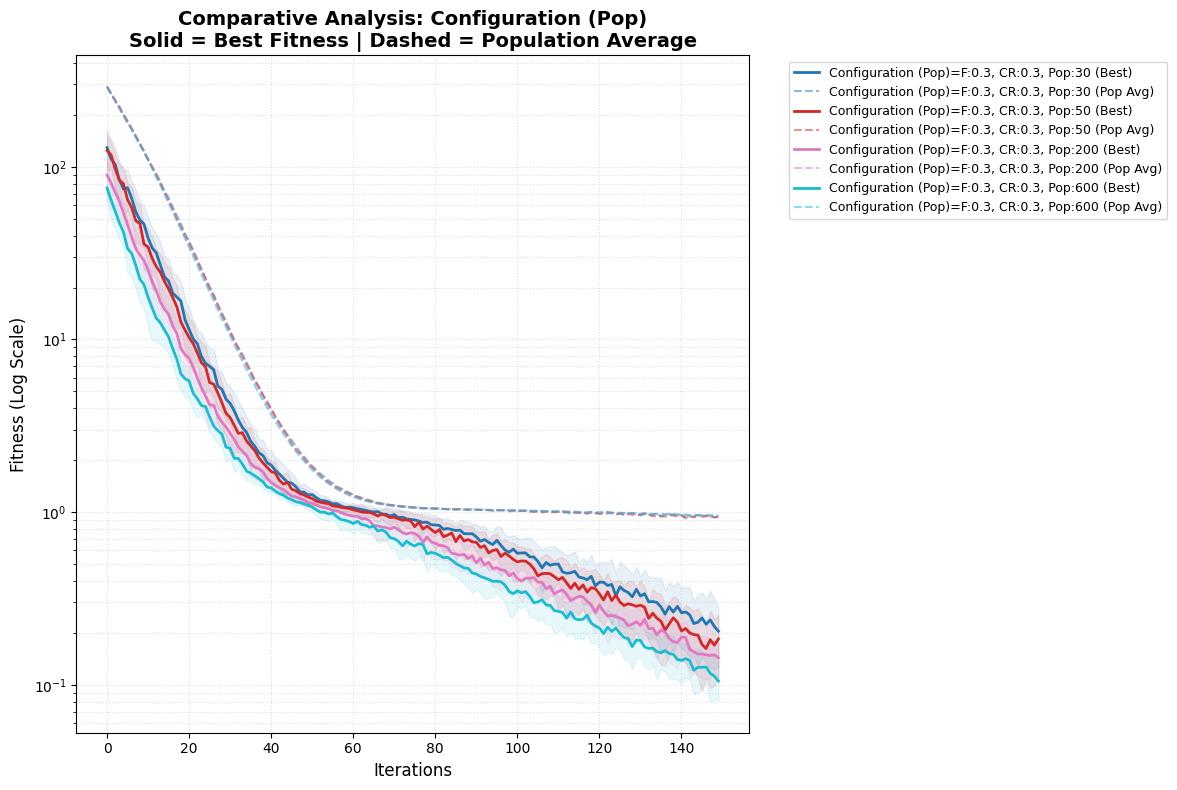

In [ ]:

dimensions = 10
lower_bound = [-600] * dimensions
upper_bound = [600] * dimensions
rounds_sweep = 30
def_F = 0.3
def_CR = 0.3
alg_name = "DE"

results_de = []
master_results = {}

print(f"Initializing Parameter Sweep - {alg_name} on Griewank {dimensions}D...")

pop_configs =  [30, 50, 200, 600]

for pop in pop_configs:
    # Extract F and CR from the current dictionary
    print(f"\nTrying {alg_name} with population {pop}", end=" ", flush=True)
    
    start = time.time()
    
    # 1. Run the experiment using the 'DE' algorithm
    # The run_experiment function already handles 'DE' when F and CR are passed in params
    result = run_experiment(
        algo_type=alg_name,
        func=griewank,
        n_dim=dimensions,
        lb=lower_bound,
        ub=upper_bound,
        params={'F': def_F, 'prob_mut': def_CR},
        rounds=rounds_sweep,
        max_iter=def_iter,
        pop=pop,
        title_suffix=f"Pop={pop}"
    )
    
    # 2. Store data for the final results table
    results_de.append({
        'Alg': alg_name,
        'Population': pop,
        'Avg Fit': result['avg'],
        'Min Fit': result['min'],
        'Std Dev': result['std']
    })
    
    # 3. Store results for the comparative plot
    label = f"F:{def_F}, CR:{def_CR}, Pop:{pop}"
    master_results[label] = result
    
    print(f"DONE! ({time.time()-start:.2f}s) | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

# DISPLAY RESULTS TABLE
df_de1 = pd.DataFrame(results_de)
print("\n" + "="*80)
print(f" RESULTS {alg_name} - GRIEWANK {dimensions}D ")
print("="*80)
print(df_de1.to_string(index=False))

# GENERATE COMPARATIVE PLOT
plot_final_comparison(
    master_results,
    var_name="Configuration (Pop)",
    filename="comparativa_final_de_griewank_pop.png"
)


### **Testing on Iterations**

Initializing Parameter Sweep - DE on Griewank 10D...

Trying DE with iteration 150 

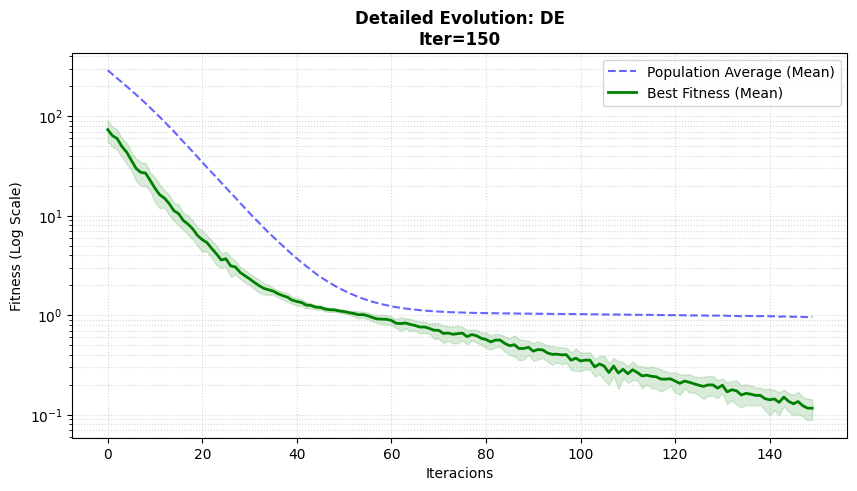

DONE! (27.37s) | Avg: 0.0855 | Min: 0.0308 | Std: 0.0174

Trying DE with iteration 300 

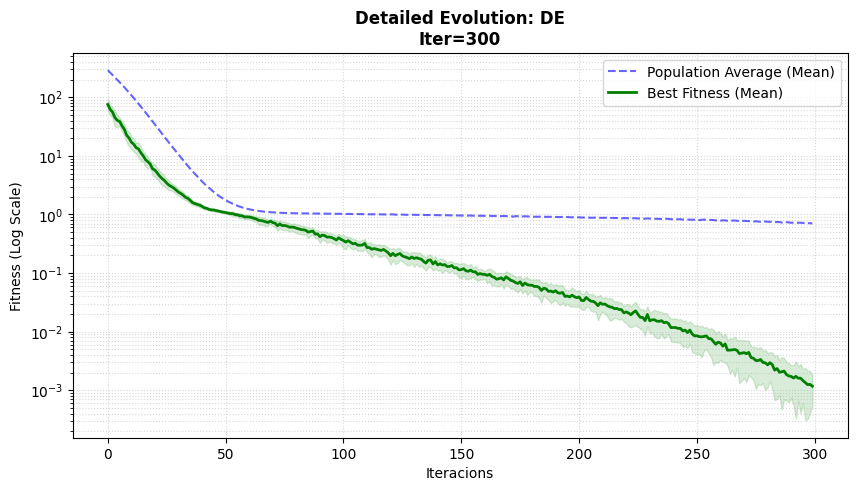

DONE! (56.57s) | Avg: 0.0009 | Min: 0.0001 | Std: 0.0005

Trying DE with iteration 600 

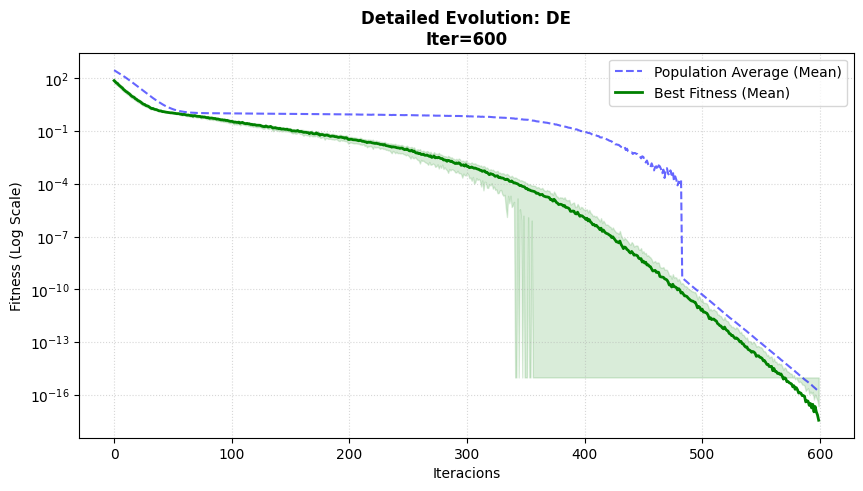

DONE! (109.67s) | Avg: 0.0000 | Min: 0.0000 | Std: 0.0000

 RESULTS DE - GRIEWANK 10D 
Alg  Iterations      Avg Fit  Min Fit      Std Dev
 DE         150 8.546635e-02 0.030789 1.740432e-02
 DE         300 8.581817e-04 0.000097 4.895897e-04
 DE         600 3.700743e-18 0.000000 1.992911e-17


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


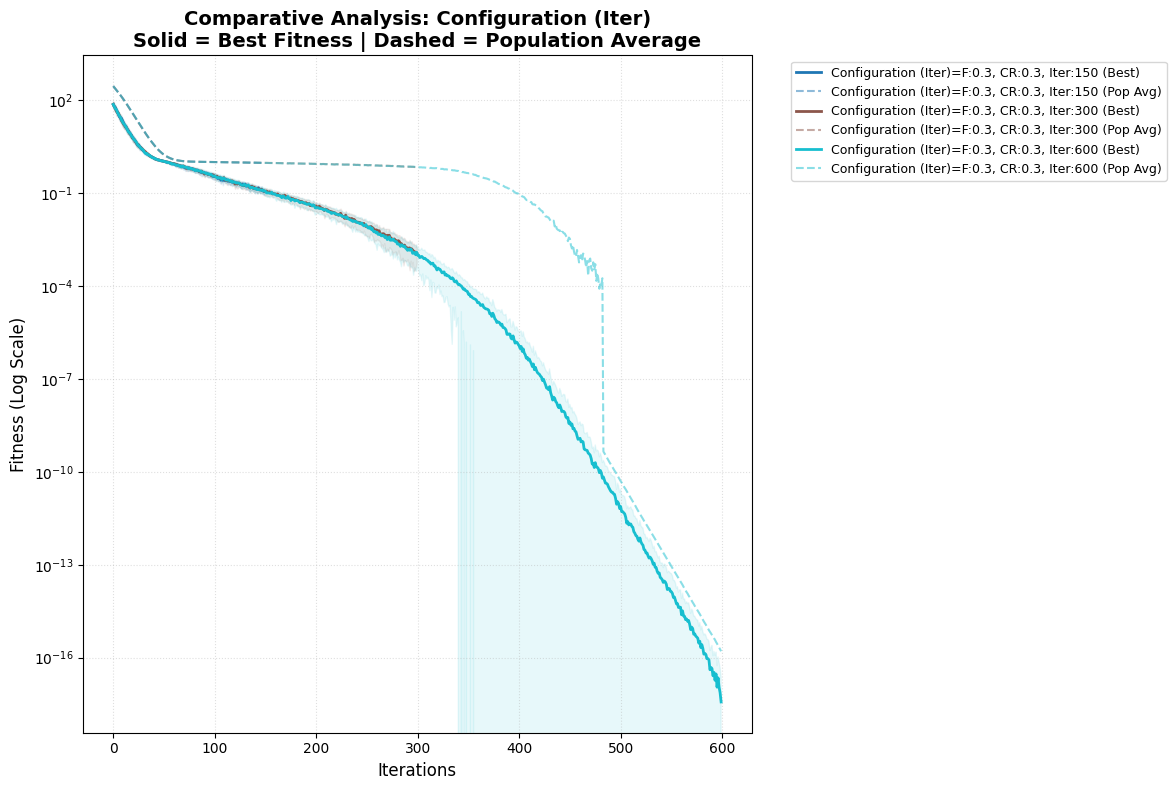

In [ ]:

dimensions = 10
lower_bound = [-600] * dimensions
upper_bound = [600] * dimensions
rounds_sweep = 30
def_F = 0.3
def_CR = 0.3
def_pop = 600
alg_name = "DE"

results_de = []
master_results = {}

print(f"Initializing Parameter Sweep - {alg_name} on Griewank {dimensions}D...")

iter_configs =  [150, 300, 600]

for iter in iter_configs:
    # Extract F and CR from the current dictionary
    print(f"\nTrying {alg_name} with iteration {iter}", end=" ", flush=True)
    
    start = time.time()
    
    # 1. Run the experiment using the 'DE' algorithm
    # The run_experiment function already handles 'DE' when F and CR are passed in params
    result = run_experiment(
        algo_type=alg_name,
        func=griewank,
        n_dim=dimensions,
        lb=lower_bound,
        ub=upper_bound,
        params={'F': def_F, 'prob_mut': def_CR},
        rounds=rounds_sweep,
        max_iter=iter,
        pop=def_pop,
        title_suffix=f"Iter={iter}"
    )
    
    # 2. Store data for the final results table
    results_de.append({
        'Alg': alg_name,
        'Iterations': iter,
        'Avg Fit': result['avg'],
        'Min Fit': result['min'],
        'Std Dev': result['std']
    })
    
    # 3. Store results for the comparative plot
    label = f"F:{def_F}, CR:{def_CR}, Iter:{iter}"
    master_results[label] = result
    
    print(f"DONE! ({time.time()-start:.2f}s) | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

# DISPLAY RESULTS TABLE
df_de1 = pd.DataFrame(results_de)
print("\n" + "="*80)
print(f" RESULTS {alg_name} - GRIEWANK {dimensions}D ")
print("="*80)
print(df_de1.to_string(index=False))

# GENERATE COMPARATIVE PLOT
plot_final_comparison(
    master_results,
    var_name="Configuration (Iter)",
    filename="comparativa_final_de_griewank_iter.png"
)


## **Rosenbrock function**

### **Testing on F & CR**

Initializing Parameter Sweep - DE on Rosenbrock 10D...

Trying DE with -> F: 0.5, CR: 0.3... 

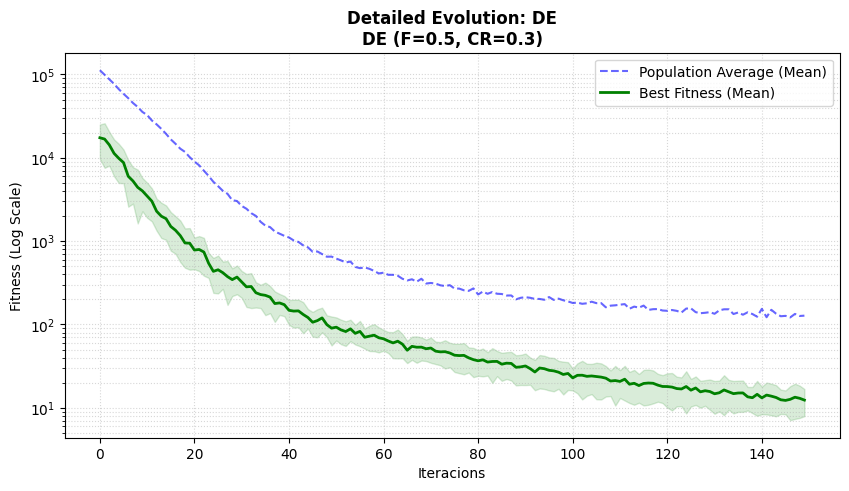

DONE! (2.42s) | Avg: 10.6520 | Min: 7.1858 | Std: 3.2660

Trying DE with -> F: 0.7, CR: 0.5... 

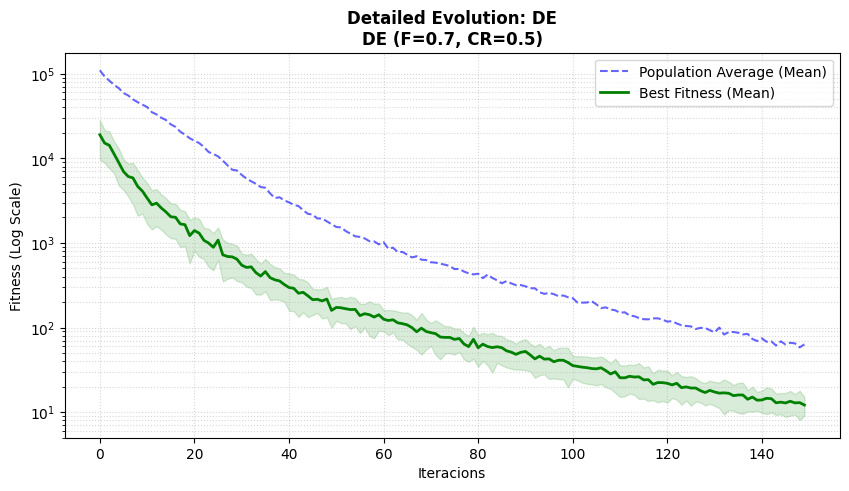

DONE! (2.39s) | Avg: 10.3520 | Min: 7.8094 | Std: 1.9219

Trying DE with -> F: 0.5, CR: 0.9... 

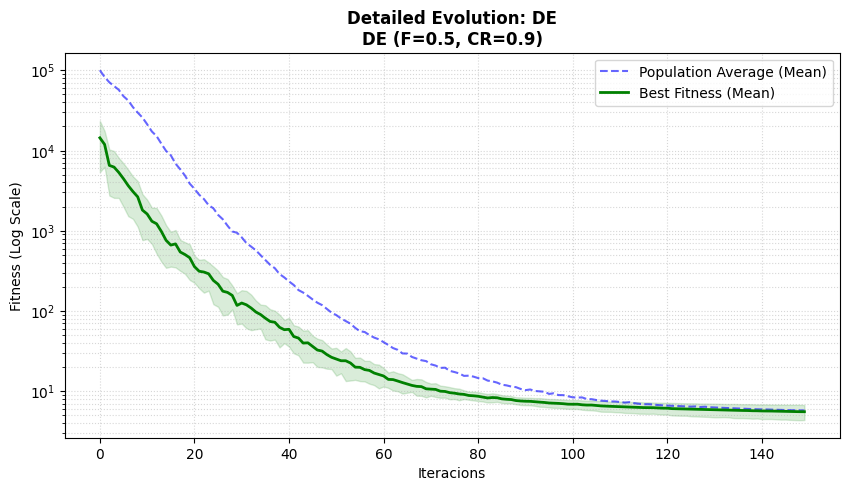

DONE! (2.31s) | Avg: 5.5321 | Min: 2.7309 | Std: 1.2107

Trying DE with -> F: 0.9, CR: 0.9... 

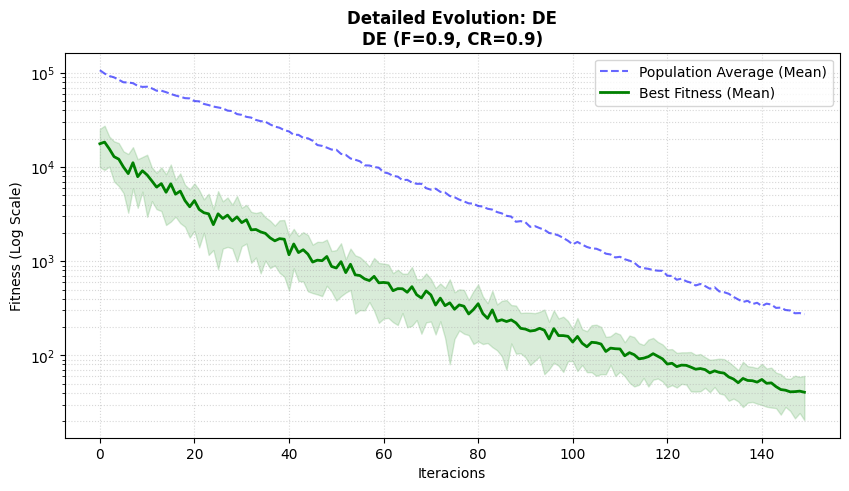

DONE! (2.28s) | Avg: 28.5311 | Min: 14.8291 | Std: 10.0983

 RESULTS DE - ROSENBROCK 10D 
Alg  F (Mutation)  CR (Crossover)   Avg Fit   Min Fit   Std Dev
 DE           0.5             0.3 10.651966  7.185805  3.266044
 DE           0.7             0.5 10.351983  7.809374  1.921897
 DE           0.5             0.9  5.532096  2.730945  1.210683
 DE           0.9             0.9 28.531120 14.829063 10.098321


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


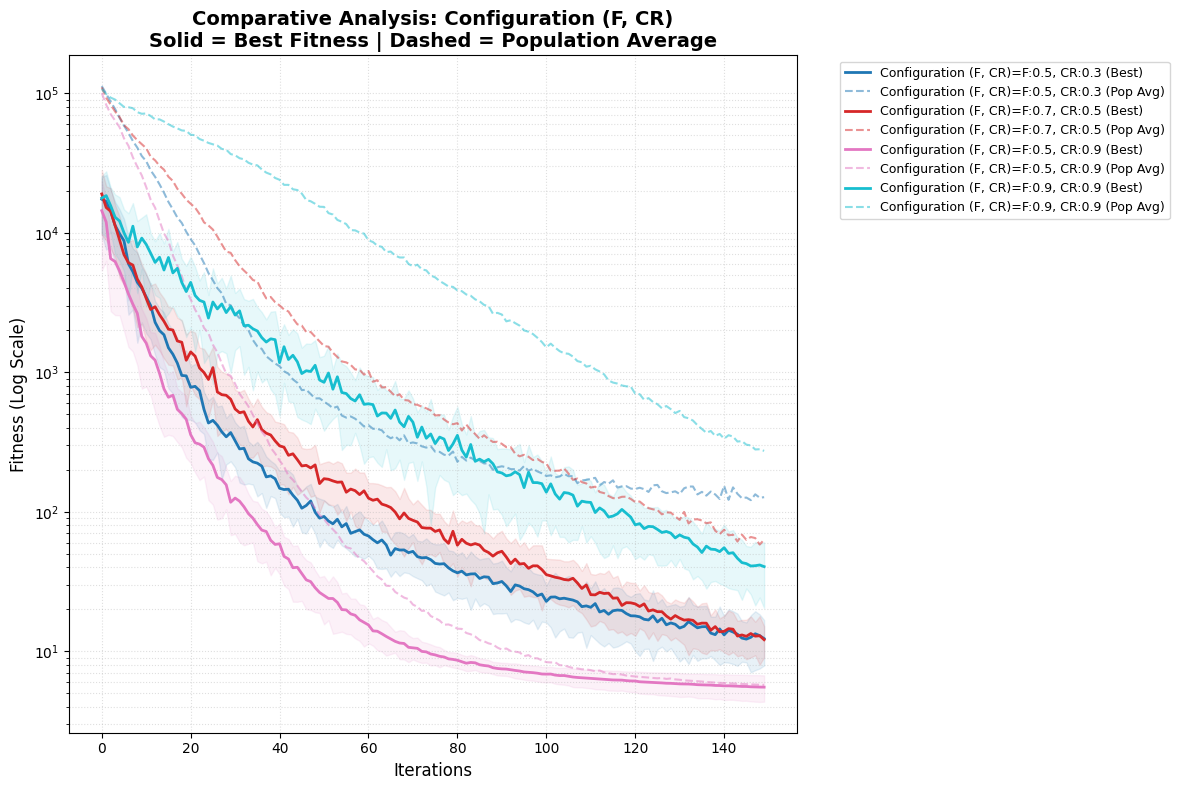

In [ ]:
# ==========================================
# CONFIGURATION FOR DIFFERENTIAL EVOLUTION (DE)
# ==========================================
dimensions = 10
lower_bound = [-5] * dimensions
upper_bound = [5] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150
alg_name = "DE"

results_de = []
master_results = {}

print(f"Initializing Parameter Sweep - {alg_name} on Rosenbrock {dimensions}D...")

# DE parameter sweep: F (Mutation) and CR (Crossover)
configs = [
    {'F': 0.5, 'prob_mut': 0.3}, # Moderate mutation, low crossover
    {'F': 0.7, 'prob_mut': 0.5}, # Balanced configuration
    {'F': 0.5, 'prob_mut': 0.9}, # Moderate mutation, high crossover
    {'F': 0.9, 'prob_mut': 0.9}  # High exploration (both F and CR high)
]

for cfg in configs:
    # Extract F and CR from the current dictionary
    f_val, cr_val = cfg['F'], cfg['prob_mut']
    print(f"\nTrying {alg_name} with -> F: {f_val}, CR: {cr_val}...", end=" ", flush=True)
    
    start = time.time()
    
    # 1. Run the experiment using the 'DE' algorithm
    result = run_experiment(
        algo_type=alg_name,
        func=rosenbrock,
        n_dim=dimensions,
        lb=lower_bound,
        ub=upper_bound,
        params=cfg,
        rounds=rounds_sweep,
        max_iter=def_iter,
        pop=def_pop,
        title_suffix=f"DE (F={f_val}, CR={cr_val})"
    )
    
    # 2. Store data for the final results table
    results_de.append({
        'Alg': alg_name,
        'F (Mutation)': f_val,
        'CR (Crossover)': cr_val,
        'Avg Fit': result['avg'],
        'Min Fit': result['min'],
        'Std Dev': result['std']
    })
    
    # 3. Store results for the comparative plot
    label = f"F:{f_val}, CR:{cr_val}"
    master_results[label] = result
    
    print(f"DONE! ({time.time()-start:.2f}s) | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

# DISPLAY RESULTS TABLE
df_de1 = pd.DataFrame(results_de)
print("\n" + "="*80)
print(f" RESULTS {alg_name} - ROSENBROCK {dimensions}D ")
print("="*80)
print(df_de1.to_string(index=False))

# GENERATE COMPARATIVE PLOT
plot_final_comparison(
    master_results,
    var_name="Configuration (F, CR)",
    filename="comparativa_f_cr_de_rosenbrock.png"
)


Initializing Parameter Sweep - DE on Rosenbrock 10D...

Trying DE with -> F: 0.5, CR: 0.9... 

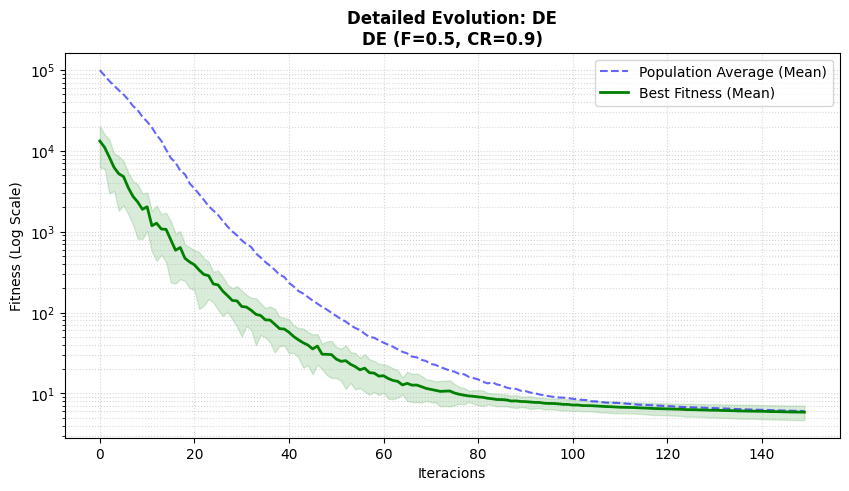

DONE! (2.59s) | Avg: 5.8446 | Min: 2.7139 | Std: 1.2026

Trying DE with -> F: 0.6, CR: 0.9... 

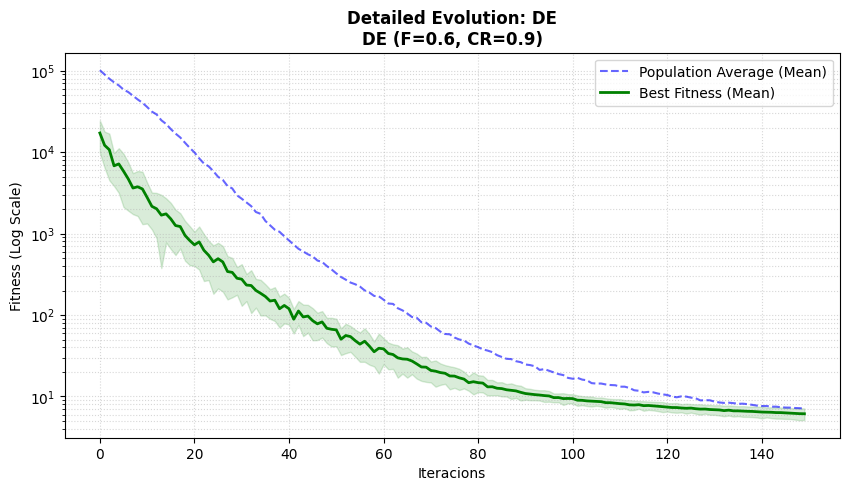

DONE! (2.34s) | Avg: 6.0468 | Min: 2.6826 | Std: 1.0072

Trying DE with -> F: 0.4, CR: 0.9... 

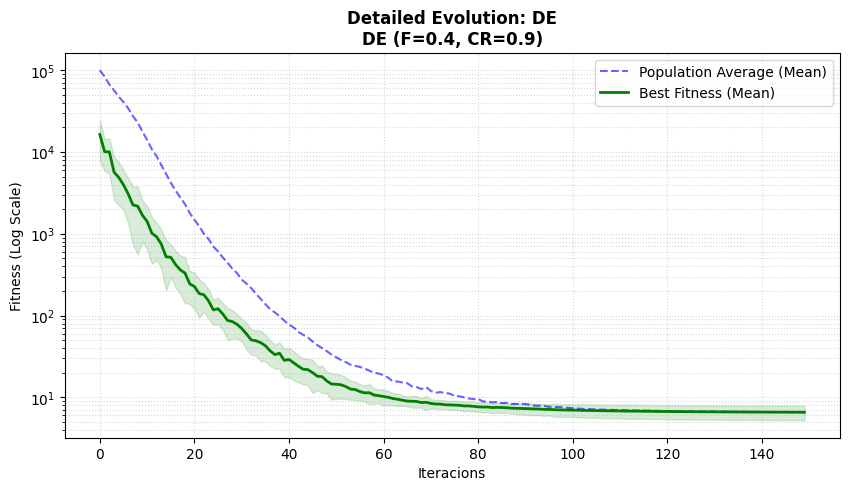

DONE! (2.37s) | Avg: 6.5703 | Min: 1.8277 | Std: 1.3225

Trying DE with -> F: 0.3, CR: 0.8... 

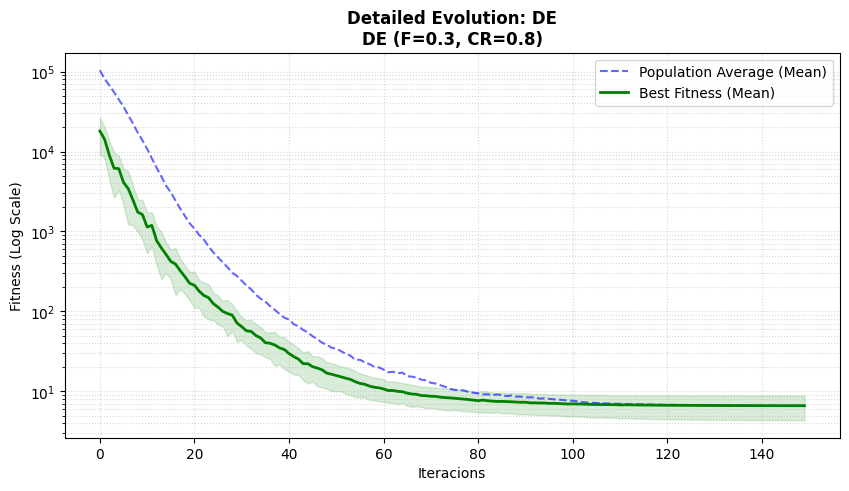

DONE! (2.30s) | Avg: 6.6286 | Min: 2.3611 | Std: 2.2638

Trying DE with -> F: 0.3, CR: 0.9... 

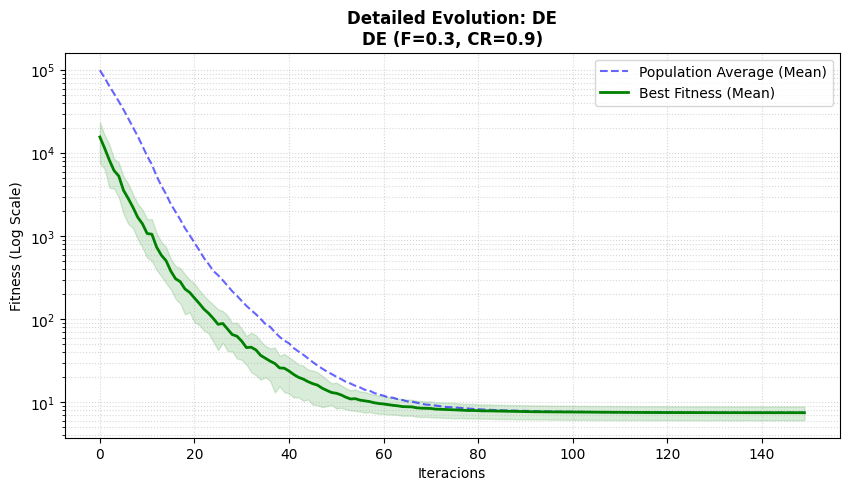

DONE! (2.32s) | Avg: 7.5152 | Min: 4.5102 | Std: 1.4152

Trying DE with -> F: 0.5, CR: 0.8... 

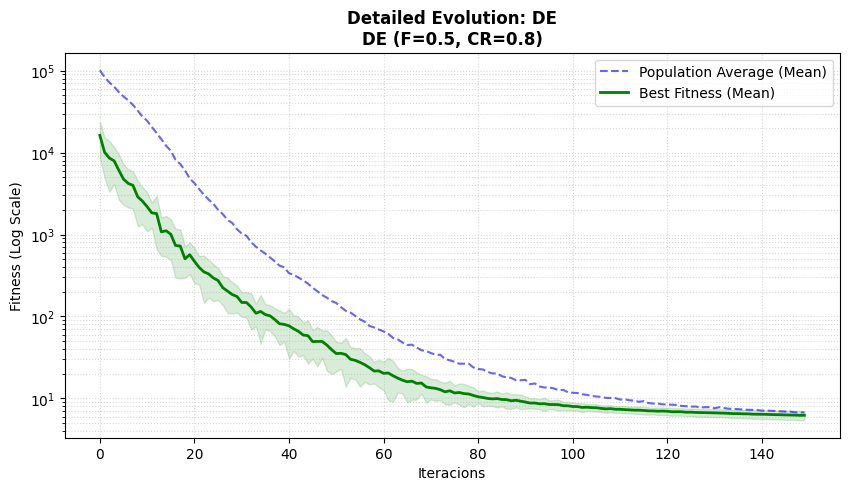

DONE! (2.36s) | Avg: 6.1811 | Min: 5.0503 | Std: 0.8062

 RESULTS DE - ROSENBROCK 10D 
Alg  F (Mutation)  CR (Crossover)  Avg Fit  Min Fit  Std Dev
 DE           0.5             0.9 5.844579 2.713874 1.202634
 DE           0.6             0.9 6.046794 2.682593 1.007181
 DE           0.4             0.9 6.570267 1.827677 1.322543
 DE           0.3             0.8 6.628558 2.361145 2.263845
 DE           0.3             0.9 7.515228 4.510242 1.415243
 DE           0.5             0.8 6.181114 5.050349 0.806241


C:\Users\enric\AppData\Local\Temp\ipykernel_11912\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


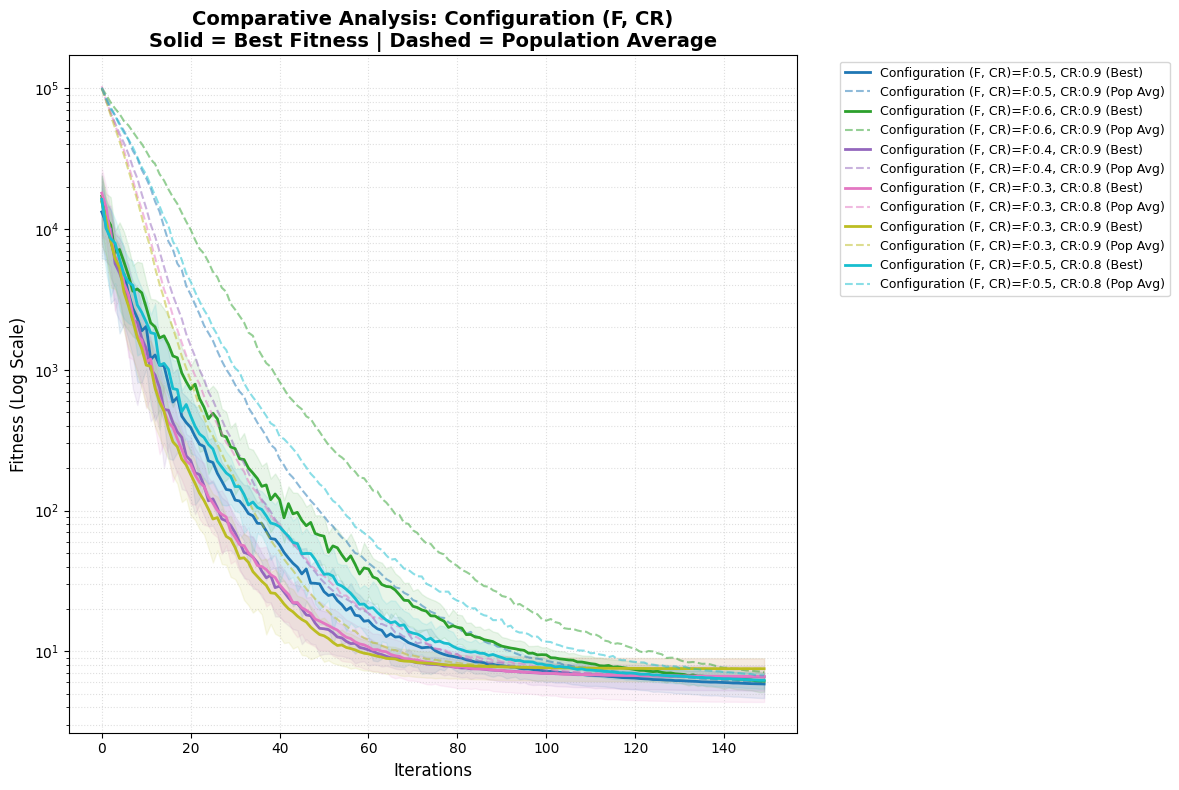

In [ ]:
# ==========================================
# CONFIGURATION FOR DIFFERENTIAL EVOLUTION (DE)
# ==========================================
dimensions = 10
lower_bound = [-5] * dimensions
upper_bound = [5] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150
alg_name = "DE"

results_de = []
master_results = {}

print(f"Initializing Parameter Sweep - {alg_name} on Rosenbrock {dimensions}D...")

# DE parameter sweep: F (Mutation) and CR (Crossover)
configs = [
    {'F': 0.5, 'prob_mut': 0.9},
    {'F': 0.6, 'prob_mut': 0.9},
    {'F': 0.4, 'prob_mut': 0.9},
    {'F': 0.3, 'prob_mut': 0.8},
    {'F': 0.3, 'prob_mut': 0.9},
    {'F': 0.5, 'prob_mut': 0.8}
]

for cfg in configs:
    # Extract F and CR from the current dictionary
    f_val, cr_val = cfg['F'], cfg['prob_mut']
    print(f"\nTrying {alg_name} with -> F: {f_val}, CR: {cr_val}...", end=" ", flush=True)
    
    start = time.time()
    
    # 1. Run the experiment using the 'DE' algorithm
    # The run_experiment function already handles 'DE' when F and CR are passed in params
    result = run_experiment(
        algo_type=alg_name,
        func=rosenbrock,
        n_dim=dimensions,
        lb=lower_bound,
        ub=upper_bound,
        params=cfg,
        rounds=rounds_sweep,
        max_iter=def_iter,
        pop=def_pop,
        title_suffix=f"DE (F={f_val}, CR={cr_val})"
    )
    
    # 2. Store data for the final results table
    results_de.append({
        'Alg': alg_name,
        'F (Mutation)': f_val,
        'CR (Crossover)': cr_val,
        'Avg Fit': result['avg'],
        'Min Fit': result['min'],
        'Std Dev': result['std']
    })
    
    # 3. Store results for the comparative plot
    label = f"F:{f_val}, CR:{cr_val}"
    master_results[label] = result
    
    print(f"DONE! ({time.time()-start:.2f}s) | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

# DISPLAY RESULTS TABLE
df_de1 = pd.DataFrame(results_de)
print("\n" + "="*80)
print(f" RESULTS {alg_name} - ROSENBROCK {dimensions}D ")
print("="*80)
print(df_de1.to_string(index=False))

# GENERATE COMPARATIVE PLOT
plot_final_comparison(
    master_results,
    var_name="Configuration (F, CR)",
    filename="comparativa_f_cr_final_de_rosenbrock.png"
)


### **Testing on Population**

Initializing Parameter Sweep - DE on Rosenbrock 10D...

Trying DE with population 30 

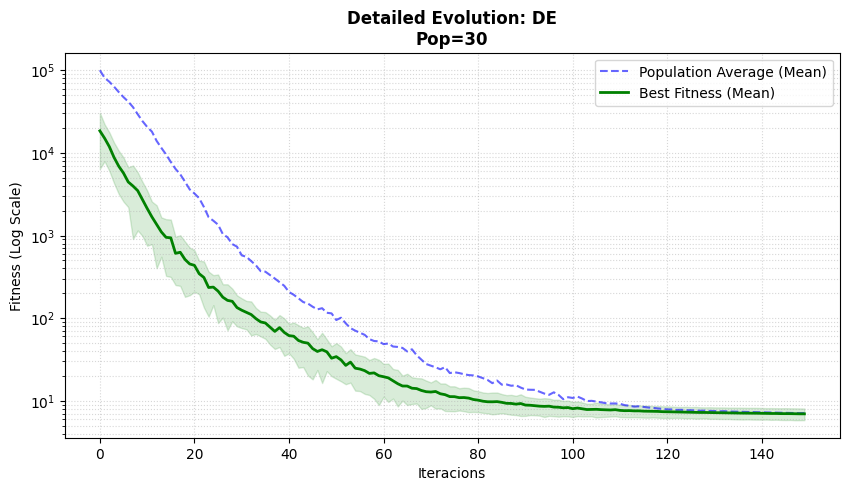

DONE! (1.70s) | Avg: 6.9266 | Min: 3.9744 | Std: 1.1356

Trying DE with population 50 

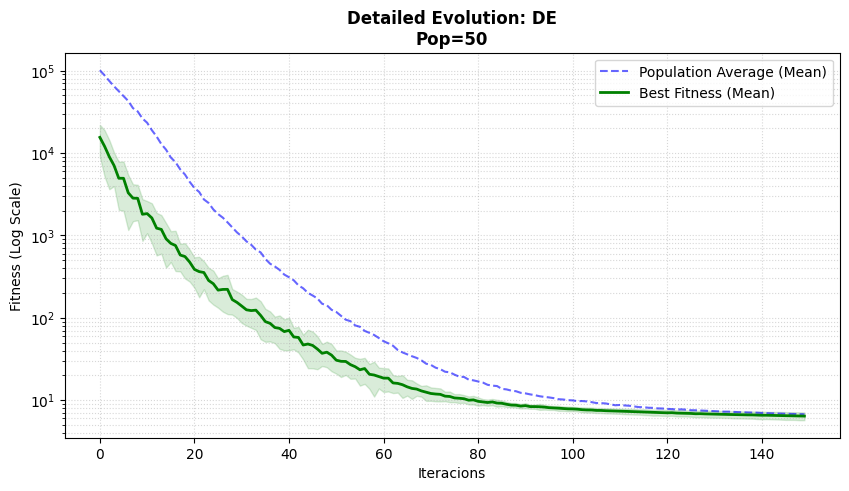

DONE! (2.35s) | Avg: 6.3705 | Min: 5.2579 | Std: 0.7110

Trying DE with population 200 

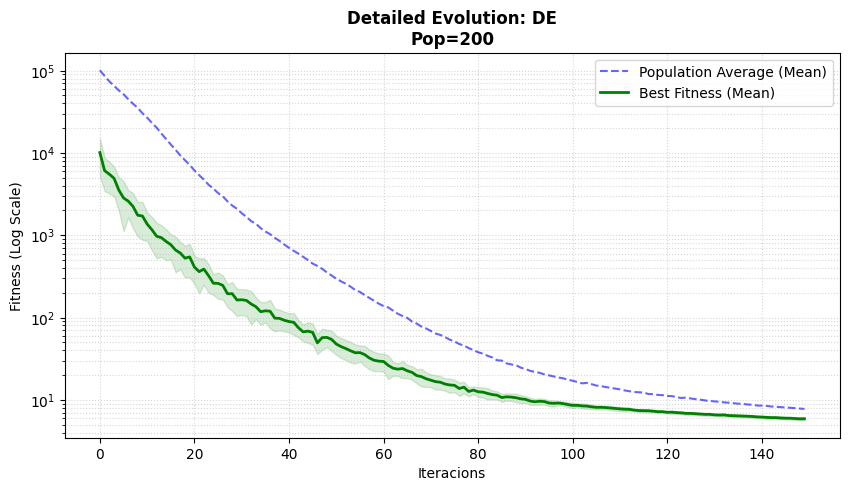

DONE! (8.43s) | Avg: 5.7758 | Min: 5.1418 | Std: 0.2137

Trying DE with population 600 

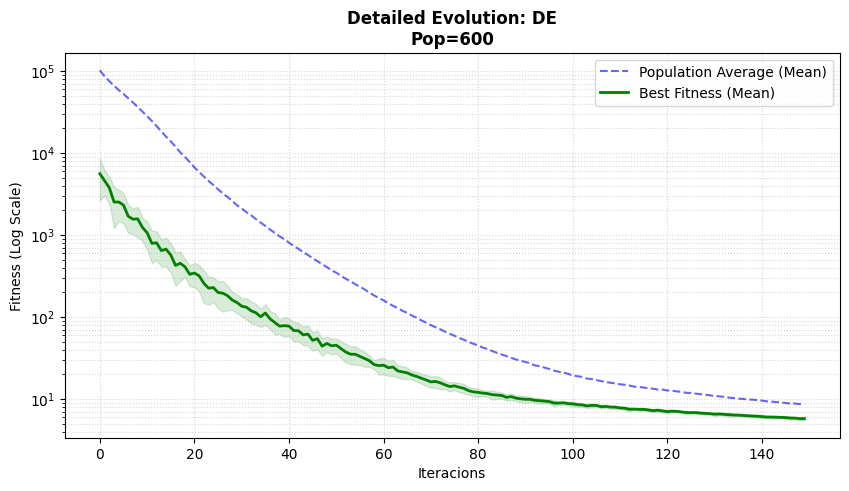

DONE! (24.06s) | Avg: 5.6445 | Min: 4.9816 | Std: 0.2424

 RESULTS DE - ROSENBROCK 10D 
Alg  Population  Avg Fit  Min Fit  Std Dev
 DE          30 6.926613 3.974404 1.135637
 DE          50 6.370480 5.257854 0.710968
 DE         200 5.775775 5.141781 0.213696
 DE         600 5.644490 4.981572 0.242364


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


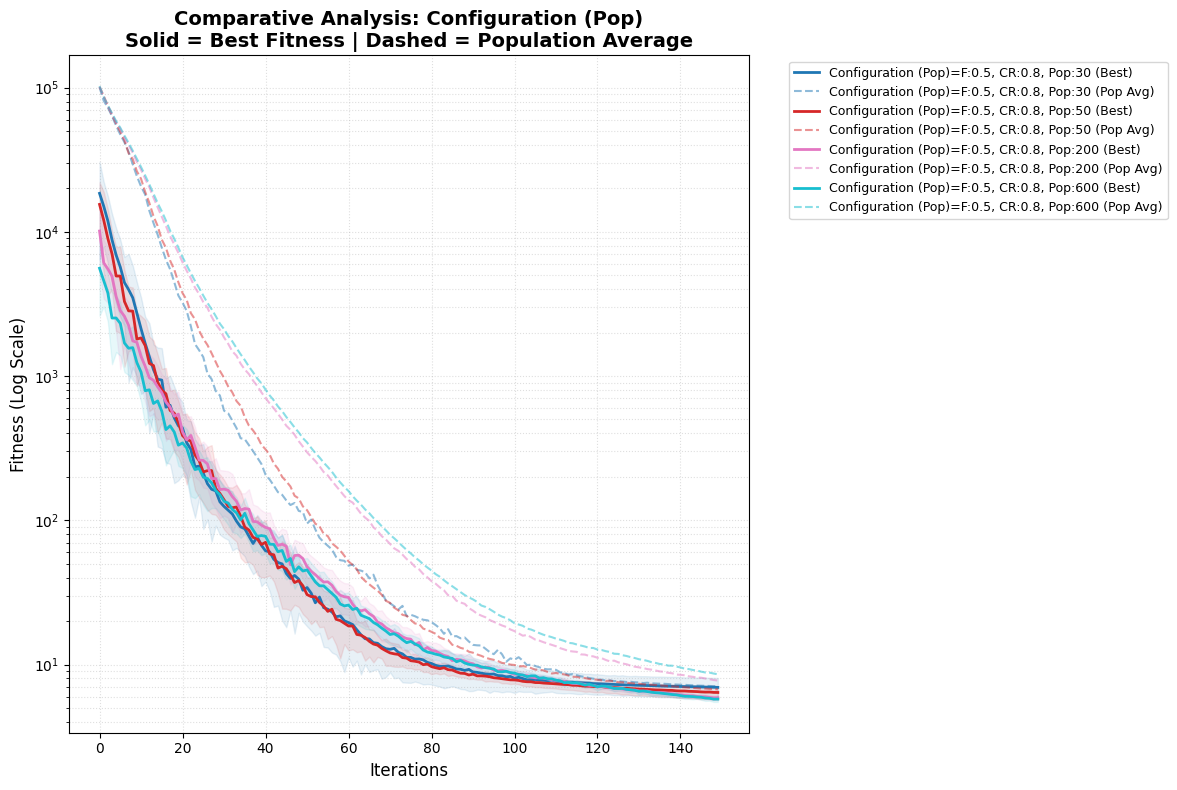

In [ ]:

dimensions = 10
lower_bound = [-5] * dimensions
upper_bound = [5] * dimensions
rounds_sweep = 30
def_F = 0.5
def_CR = 0.8
alg_name = "DE"

results_de = []
master_results = {}

print(f"Initializing Parameter Sweep - {alg_name} on Rosenbrock {dimensions}D...")

pop_configs =  [30, 50, 200, 600]

for pop in pop_configs:
    print(f"\nTrying {alg_name} with population {pop}", end=" ", flush=True)
    
    start = time.time()
    
    # 1. Run the experiment using the 'DE' algorithm
    result = run_experiment(
        algo_type=alg_name,
        func=rosenbrock,
        n_dim=dimensions,
        lb=lower_bound,
        ub=upper_bound,
        params={'F': def_F, 'prob_mut': def_CR},
        rounds=rounds_sweep,
        max_iter=def_iter,
        pop=pop,
        title_suffix=f"Pop={pop}"
    )
    
    # 2. Store data for the final results table
    results_de.append({
        'Alg': alg_name,
        'Population': pop,
        'Avg Fit': result['avg'],
        'Min Fit': result['min'],
        'Std Dev': result['std']
    })
    
    # 3. Store results for the comparative plot
    label = f"F:{def_F}, CR:{def_CR}, Pop:{pop}"
    master_results[label] = result
    
    print(f"DONE! ({time.time()-start:.2f}s) | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

# DISPLAY RESULTS TABLE
df_de1 = pd.DataFrame(results_de)
print("\n" + "="*80)
print(f" RESULTS {alg_name} - ROSENBROCK {dimensions}D ")
print("="*80)
print(df_de1.to_string(index=False))

# GENERATE COMPARATIVE PLOT
plot_final_comparison(
    master_results,
    var_name="Configuration (Pop)",
    filename="comparativa_final_de_rosenbrock_pop.png"
)


### **Testing on Iterations**

Initializing Parameter Sweep - DE on Rosenbrock 10D...

Trying DE with iteration 150 

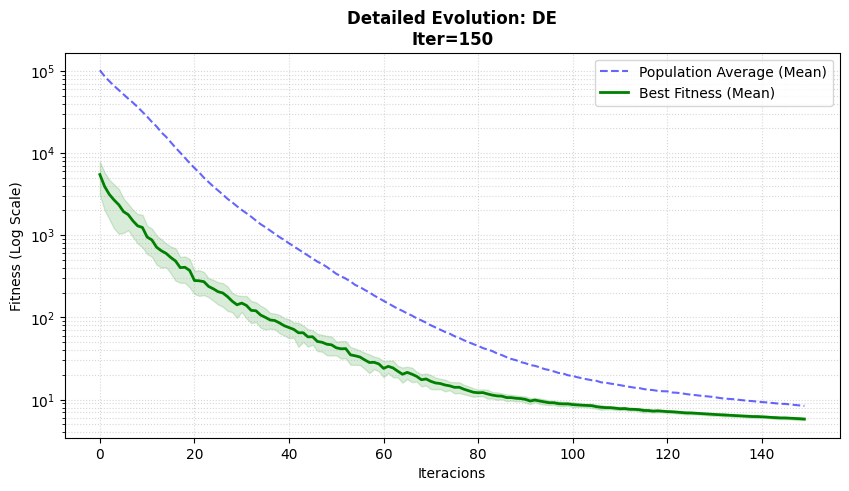

DONE! (24.19s) | Avg: 5.7183 | Min: 5.2624 | Std: 0.1874

Trying DE with iteration 300 

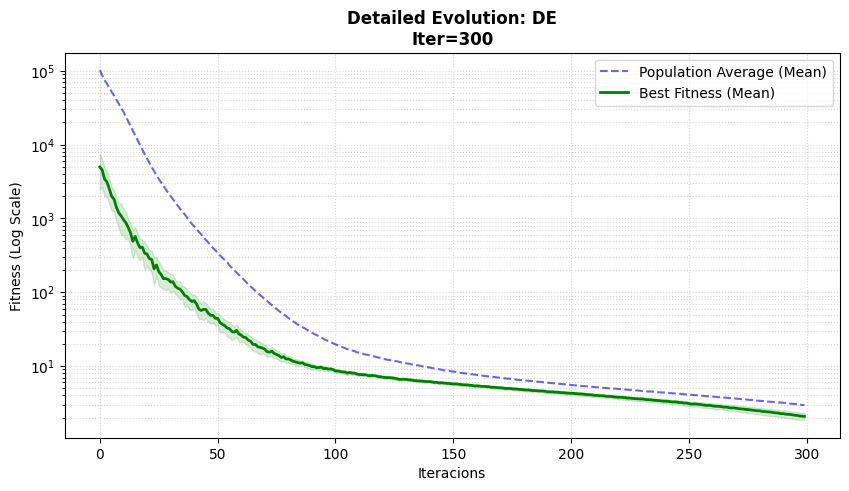

DONE! (48.07s) | Avg: 2.0350 | Min: 1.6062 | Std: 0.2407

Trying DE with iteration 600 

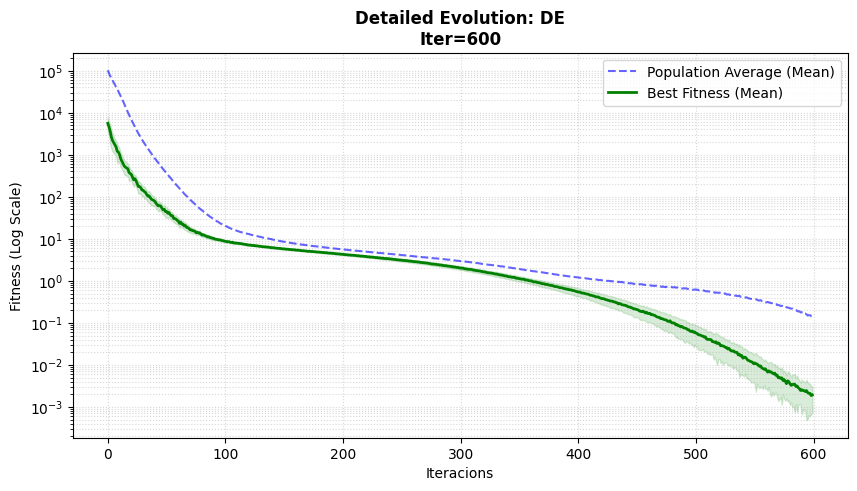

DONE! (96.27s) | Avg: 0.0013 | Min: 0.0005 | Std: 0.0007

 RESULTS DE - ROSENBROCK 10D 
Alg  Iterations  Avg Fit  Min Fit  Std Dev
 DE         150 5.718332 5.262399 0.187409
 DE         300 2.034989 1.606199 0.240675
 DE         600 0.001277 0.000460 0.000714


C:\Users\enric\AppData\Local\Temp\ipykernel_21644\930536388.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


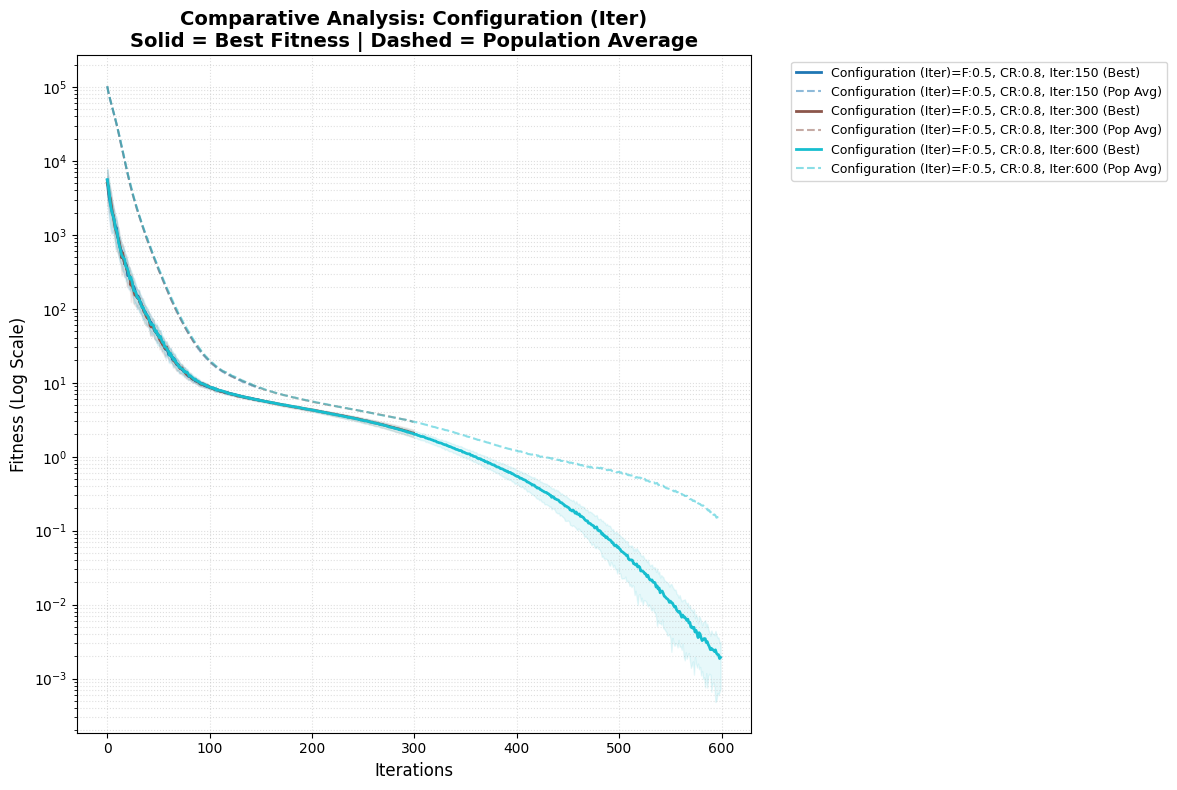

In [ ]:

dimensions = 10
lower_bound = [-5] * dimensions
upper_bound = [5] * dimensions
rounds_sweep = 30
def_F = 0.5
def_CR = 0.8
def_pop = 600
alg_name = "DE"

results_de = []
master_results = {}

print(f"Initializing Parameter Sweep - {alg_name} on Rosenbrock {dimensions}D...")

iter_configs =  [150, 300, 600]

for iter in iter_configs:
    print(f"\nTrying {alg_name} with iteration {iter}", end=" ", flush=True)
    
    start = time.time()
    
    # 1. Run the experiment using the 'DE' algorithm
    result = run_experiment(
        algo_type=alg_name,
        func=rosenbrock,
        n_dim=dimensions,
        lb=lower_bound,
        ub=upper_bound,
        params={'F': def_F, 'prob_mut': def_CR},
        rounds=rounds_sweep,
        max_iter=iter,
        pop=def_pop,
        title_suffix=f"Iter={iter}"
    )
    
    # 2. Store data for the final results table
    results_de.append({
        'Alg': alg_name,
        'Iterations': iter,
        'Avg Fit': result['avg'],
        'Min Fit': result['min'],
        'Std Dev': result['std']
    })
    
    # 3. Store results for the comparative plot
    label = f"F:{def_F}, CR:{def_CR}, Iter:{iter}"
    master_results[label] = result
    
    print(f"DONE! ({time.time()-start:.2f}s) | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

# DISPLAY RESULTS TABLE
df_de1 = pd.DataFrame(results_de)
print("\n" + "="*80)
print(f" RESULTS {alg_name} - ROSENBROCK {dimensions}D ")
print("="*80)
print(df_de1.to_string(index=False))

# GENERATE COMPARATIVE PLOT
plot_final_comparison(
    master_results,
    var_name="Configuration (Iter)",
    filename="comparativa_final_de_rosenbrock_iter.png"
)
